# ML Classification: Predicting BNI Pain Score at Last Follow-Up
**Dataset:** UpdatedTNMVD.csv — 322 MVD patients, UPMC  
**Target:** `BNI pain score Last FU` — Binary: 0 (success) / 1 (failure)  
**Class imbalance:** ~80/20 split

## 1. Setup & Data Loading

In [1]:
# ── Silence warnings (parent process + joblib subprocesses) ──
import os, warnings
os.environ['PYTHONWARNINGS'] = 'ignore'
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate,
    GridSearchCV, RandomizedSearchCV
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve,
    classification_report, average_precision_score
)
from sklearn.calibration import calibration_curve
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.inspection import permutation_importance

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import xgboost as xgb
import lightgbm as lgb
import shap

from scipy import stats

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 60)
plt.rcParams.update({'figure.dpi': 100, 'font.size': 11})
RANDOM_STATE = 42

print('All libraries loaded successfully.')

All libraries loaded successfully.


In [2]:
from pathlib import Path

# Look for the data file alongside the notebook first, then fall back to legacy locations
candidates = [
    Path('UpdatedTNMVD.xlsx'),                      # local (preferred for repo)
    Path('UpdatedTNMVD.csv'),                       # local CSV variant
    Path.home() / 'Desktop' / 'UpdatedTNMVD.xlsx',  # legacy desktop location
]

data_path = next((p for p in candidates if p.exists()), None)
if data_path is None:
    raise FileNotFoundError(
        'Could not find UpdatedTNMVD data file. Tried:\n  - '
        + '\n  - '.join(str(p.resolve()) for p in candidates)
    )

if data_path.suffix.lower() == '.csv':
    df_raw = pd.read_csv(data_path)
else:
    df_raw = pd.read_excel(data_path)

print(f'Loaded data from: {data_path.resolve()}')
print(f'Shape: {df_raw.shape}')
print(f'\nTarget distribution:')
print(df_raw['BNI pain score Last FU'].value_counts(dropna=False))
df_raw.head(3)

Loaded data from: /Users/peaceodiase/Desktop/UpdatedTNMVD.xlsx
Shape: (322, 39)

Target distribution:
BNI pain score Last FU
0    259
1     63
Name: count, dtype: int64


,Patient ID,The primary surgical treament used for TN,Trigeminal neuralgia laterality,Gender,Subtype\nFor classical or idopathic TN,BNI pain score\nBaseline,BNI Numbness score\nBaseline,Sensory abnormalities\nOther than numbness,Compressing vessel \nBy radiologic report (MRI/MRTA),Neuovascular conflict (NVC) severity\nBy radiologic report (MRI/MRTA),Compressing vessel (By intraoperative findings ),Neuovascular conflict (NVC) severity,Surgical approach,Surgical technique,Indication for Surgical Treatment,BMI,Age at surgery,Age at TN diagnosis,Number of TN drugs,Duration from TN dx to MVD (Months),Length of hospital stay (days),Cardiovascular disease,Diabetes mellitus,Hypertension,Depression,Multiple sclerosis (MS),V1 is involved,V2 is involved,V3 is involved,Trigger point,Night-time pain\nDeﬁned as painful awakenings at night because of pain attacks at least occasionally,Carbamezepine,Gabapentin,Phenytoin,Baclofen,Oxcarbamazepine,Pregabalin,Lamotrigine,BNI pain score Last FU
0,UPMC049,MVD,Left,Female,Paroxysmal,IV,I,Allodynia,Arterial,I,Arterial,I,Retrosigmoid Approach,Interposition,Failed Medication,21.93,57.0,29.0,1.0,0.0,1,0,0,0,0,0,1.0,1.0,1.0,1.0,0.0,1,0,0,0,0,0,0,1
1,UPMC111,MVD,Right,Female,Concomittant Pain,IIIb,I,Allodynia,Venous,I,Arterial,I,Retrosigmoid Approach,Interposition,Failed Medication,22.05,79.0,38.0,3.0,12.0,2,0,0,1,1,0,1.0,1.0,1.0,0.0,0.0,0,1,1,0,1,0,0,1
2,UPMC352,MVD,Left,Female,Paroxysmal,IIIb,I,Allodynia,Arterial and Venous,I,Arterial,II,Retrosigmoid Approach,Interposition,Both,23.40,69.0,54.0,2.0,12.0,1,0,0,1,0,0,0.0,1.0,1.0,1.0,0.0,1,1,0,0,0,0,0,1


## 2. Exploratory Data Analysis (EDA)

### What is EDA and why do we do it?

Before fitting any model, we need to **understand the data** deeply. Exploratory Data Analysis answers three fundamental questions:

1. **Quality:** Are there missing values, data entry errors, or impossible values? (e.g., negative hospital stay, BMI of 4.2)
2. **Distribution:** What do the features look like? Are numeric variables skewed? Do categorical variables have rare categories?
3. **Signal:** Do any features already *visually* separate the two classes? This tells us which features are likely to matter most.

The steps below work through each of these in turn. We first rename all columns to clean, short identifiers (the raw column names contain newlines and trailing spaces from the Excel export), then examine missingness, class balance, feature distributions, and outliers.

In [3]:
# ── Column rename map: clean up newlines and trailing spaces ──
rename_map = {
    'The primary surgical treament used for TN': 'surgical_treatment',
    'Trigeminal neuralgia laterality ': 'laterality',
    'Gender': 'gender',
    'Subtype\nFor classical or idopathic TN': 'subtype',
    'BNI pain score\nBaseline': 'bni_baseline',
    'BNI Numbness score\nBaseline': 'bni_numbness_baseline',
    'Sensory abnormalities\nOther than numbness ': 'sensory_abnormalities',
    'Compressing vessel \nBy radiologic report (MRI/MRTA) ': 'vessel_radiologic',
    'Neuovascular conflict (NVC) severity\nBy radiologic report (MRI/MRTA) ': 'nvc_radiologic',
    'Compressing vessel (By intraoperative findings )': 'vessel_intraop',
    'Neuovascular conflict (NVC) severity': 'nvc_intraop',
    'Surgical approach ': 'surgical_approach',
    'Surgical technique': 'surgical_technique',
    'Indication for Surgical Treatment': 'surgical_indication',
    'BMI': 'bmi',
    'Age at surgery': 'age_surgery',
    'Age at TN diagnosis ': 'age_diagnosis',
    'Number of TN drugs': 'num_drugs',
    'Duration from TN dx to MVD (Months)': 'duration_months',
    'Length of hospital stay  (days)': 'hospital_stay',
    'Cardiovascular disease ': 'cardiovascular',
    'Diabetes mellitus': 'diabetes',
    'Hypertension': 'hypertension',
    'Depression': 'depression',
    'Multiple sclerosis (MS)': 'ms',
    'V1 is involved': 'v1',
    'V2 is involved': 'v2',
    'V3 is involved': 'v3',
    'Trigger point': 'trigger_point',
    'Night-time pain\nDe\ufb01ned as painful awakenings at night because of pain attacks at least occasionally': 'night_pain',
    'Carbamezepine': 'carbamazepine',
    'Gabapentin': 'gabapentin',
    'Phenytoin': 'phenytoin',
    'Baclofen': 'baclofen',
    'Oxcarbamazepine': 'oxcarbamazepine',
    'Pregabalin': 'pregabalin',
    'Lamotrigine': 'lamotrigine',
    'BNI pain score Last FU': 'target',
    'Patient ID': 'patient_id',
}

df = df_raw.rename(columns=rename_map).copy()
print('Columns after rename:')
print(df.columns.tolist())

Columns after rename:
['patient_id', 'surgical_treatment', 'laterality', 'gender', 'subtype', 'bni_baseline', 'bni_numbness_baseline', 'sensory_abnormalities', 'vessel_radiologic', 'nvc_radiologic', 'vessel_intraop', 'nvc_intraop', 'surgical_approach', 'surgical_technique', 'surgical_indication', 'bmi', 'age_surgery', 'age_diagnosis', 'num_drugs', 'duration_months', 'hospital_stay', 'cardiovascular', 'diabetes', 'hypertension', 'depression', 'ms', 'v1', 'v2', 'v3', 'trigger_point', 'night_pain', 'carbamazepine', 'gabapentin', 'phenytoin', 'baclofen', 'oxcarbamazepine', 'pregabalin', 'lamotrigine', 'target']


In [4]:
# ── Missing value analysis ──
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'count': missing, 'pct': missing_pct})
missing_df = missing_df[missing_df['count'] > 0].sort_values('count', ascending=False)
print('Missing values:\n')
print(missing_df.to_string())

Missing values:

                       count   pct
sensory_abnormalities    210  65.2
nvc_radiologic            22   6.8
vessel_radiologic         19   5.9
v2                         9   2.8
nvc_intraop                9   2.8
v3                         9   2.8
v1                         9   2.8
vessel_intraop             7   2.2
surgical_indication        7   2.2
bmi                        3   0.9
bni_numbness_baseline      3   0.9
num_drugs                  3   0.9
surgical_approach          2   0.6
surgical_technique         2   0.6
age_diagnosis              2   0.6
trigger_point              1   0.3
bni_baseline               1   0.3
duration_months            1   0.3
age_surgery                1   0.3
night_pain                 1   0.3


### Missing Data

The table above shows which features have missing values and how severe the missingness is. The most important findings:

- **`sensory_abnormalities` (65.3% missing):** This is the most incomplete feature. The most likely explanation is that patients *without* sensory abnormalities had nothing to record — i.e., a blank entry means "None." This is called **missing not at random (MNAR)**, and we handle it by treating the missing value itself as a category ("None" after imputation).
- **NVC severity columns (3–7% missing):** These are likely cases where imaging was unavailable or the operative note was incomplete. We impute these with the most frequent value.
- **Most binary comorbidities (< 2% missing):** Very low missingness, safe to impute with mode (most common value = 0, i.e., absent).

> **Why does missingness matter?** If we simply delete rows with any missing value we would lose a large fraction of our dataset (especially due to `sensory_abnormalities`). Instead, we use **imputation** — filling in missing values with a reasonable estimate — so we keep all 322 patients.

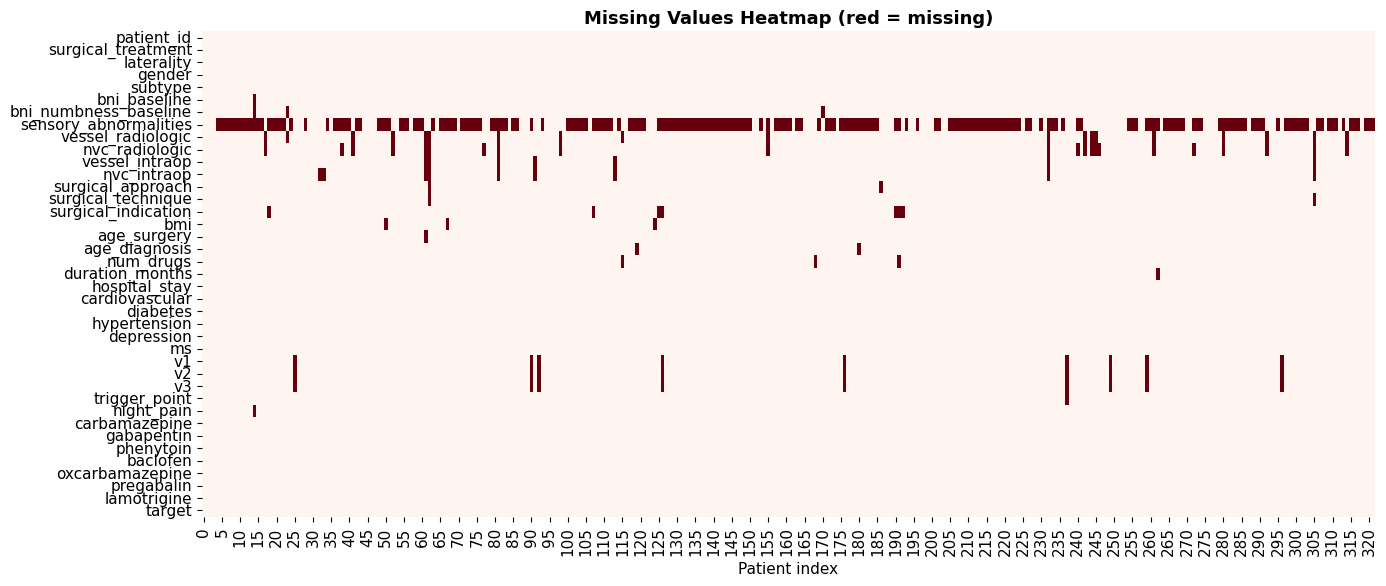

In [5]:
# ── Missing value heatmap ──
fig, ax = plt.subplots(figsize=(14, 6))
missing_matrix = df.isnull().astype(int)
sns.heatmap(missing_matrix.T, cmap='Reds', cbar=False, ax=ax, yticklabels=True)
ax.set_title('Missing Values Heatmap (red = missing)', fontsize=13, fontweight='bold')
ax.set_xlabel('Patient index')
plt.tight_layout()
plt.savefig('missing_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()

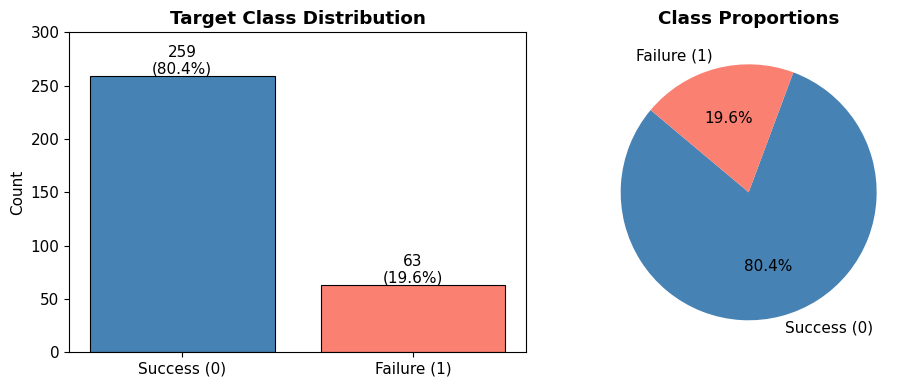

In [6]:
# ── Class balance ──
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
target_counts = df['target'].dropna().value_counts()
axes[0].bar(['Success (0)', 'Failure (1)'], target_counts.values,
            color=['steelblue', 'salmon'], edgecolor='black', linewidth=0.8)
for i, (v, n) in enumerate(zip(target_counts.values,
                                [f'{target_counts[0]/target_counts.sum()*100:.1f}%',
                                 f'{target_counts[1]/target_counts.sum()*100:.1f}%'])):
    axes[0].text(i, v + 2, f'{v}\n({n})', ha='center', fontsize=11)
axes[0].set_title('Target Class Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_ylim(0, 300)

axes[1].pie(target_counts.values, labels=['Success (0)', 'Failure (1)'],
            colors=['steelblue', 'salmon'], autopct='%1.1f%%', startangle=140)
axes[1].set_title('Class Proportions', fontweight='bold')
plt.tight_layout()
plt.savefig('class_balance.png', dpi=100, bbox_inches='tight')
plt.show()

### Class Imbalance

The target variable is **heavily imbalanced**: ~80% of patients had a successful outcome (class 0) and only ~20% had treatment failure (class 1). This creates a serious problem for machine learning:

> A model that **always predicts "success"** would be right 80% of the time — but it would never catch a single failure, which is exactly what we clinically care about detecting.

This is why **accuracy is a misleading metric here**. We will focus on **AUC-ROC** (which is insensitive to class balance) and **sensitivity/recall** (how many true failures we catch).

We address imbalance through three complementary strategies:
1. `class_weight='balanced'` — tells the model to penalise misclassifying the minority class (failures) proportionally more
2. **SMOTE** (Synthetic Minority Oversampling TEchnique) — synthetically generates new minority-class training examples
3. **Threshold tuning** — adjusting the probability cut-off from the default 0.50 to a lower value to catch more failures at the cost of some false alarms

In [7]:
# ── BNI Baseline vs Target cross-tabulation ──
ct = pd.crosstab(df['bni_baseline'], df['target'],
                 margins=True, margins_name='Total')
ct.columns = ['Success (0)', 'Failure (1)', 'Total']
ct['Failure Rate'] = (ct['Failure (1)'] / ct['Total'] * 100).round(1).astype(str) + '%'
print('BNI Baseline vs Last FU Outcome:\n')
print(ct)

BNI Baseline vs Last FU Outcome:

              Success (0)  Failure (1)  Total Failure Rate
bni_baseline                                              
I                       2            0      2         0.0%
IIIb                    6            4     10        40.0%
IV                    197           47    244        19.3%
V                      54           11     65        16.9%
Total                 259           62    321        19.3%


### BNI Baseline vs. Last Follow-Up — Is the Target Just a Threshold of Baseline?

A critical question before modelling: **is the target variable (`BNI Last FU`) simply determined by the baseline BNI score?** If so, including baseline in the feature set would be "giving the model the answer" (data leakage).

The cross-tabulation above shows that **no single baseline BNI value deterministically predicts outcome**:
- Patients with baseline BNI IV (the most common) failed 19.3% of the time
- Patients with baseline BNI V (most severe) actually failed *less* often (16.9%) — likely because surgeons selected the most suitable candidates
- Even the small IIIb group had a 40% failure rate

**Conclusion:** Baseline BNI is a clinical predictor, not a mathematical encoding of the outcome. We **exclude it from the feature set** to avoid leakage and to force the model to learn from independent clinical variables. The model's job is to predict *which patients with severe baseline pain will still fail despite MVD surgery*.

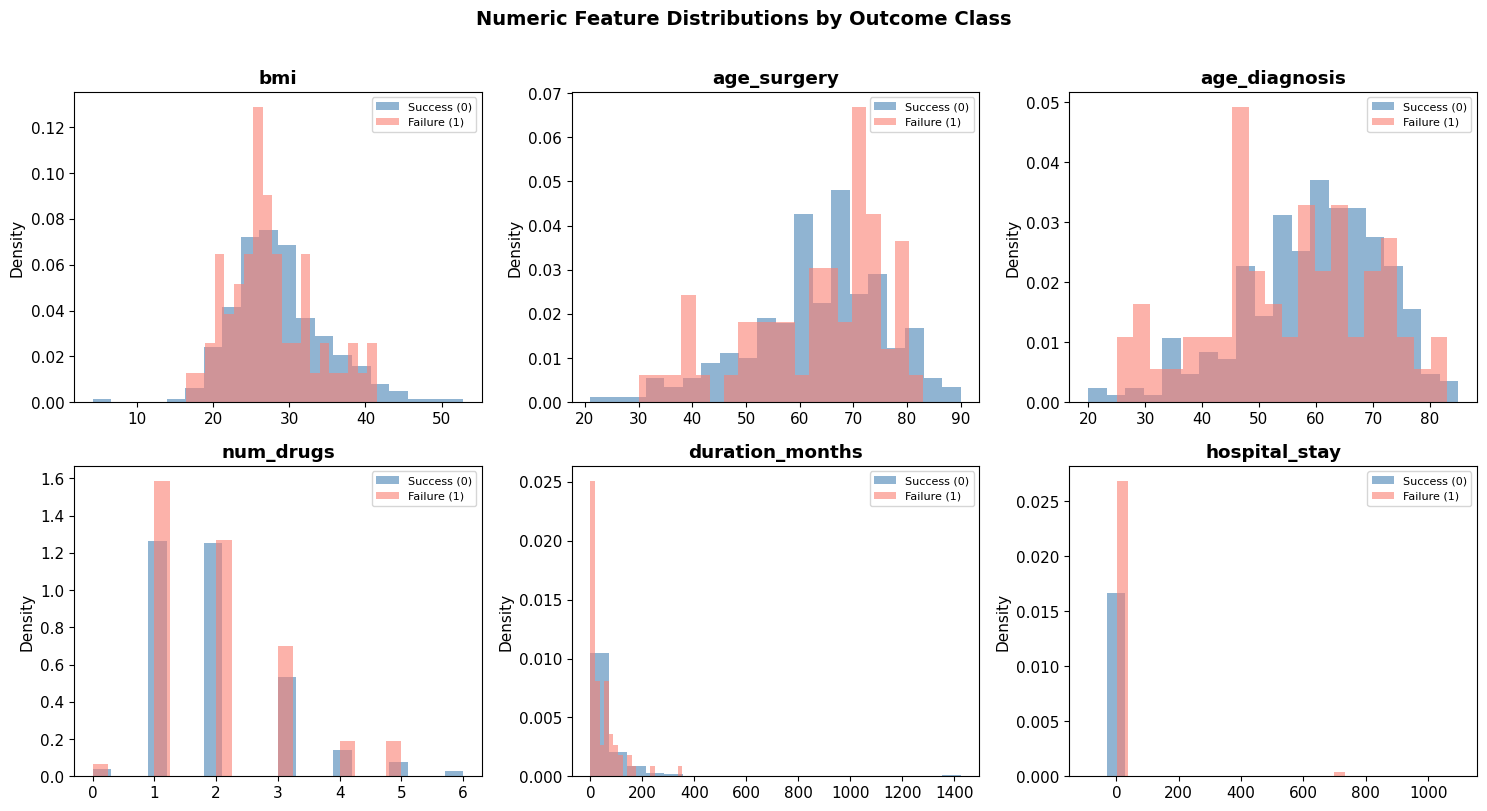

In [8]:
# ── Numeric feature distributions by class ──
numeric_features = ['bmi', 'age_surgery', 'age_diagnosis', 'num_drugs', 'duration_months', 'hospital_stay']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(numeric_features):
    data_0 = df[df['target'] == 0][feat].dropna()
    data_1 = df[df['target'] == 1][feat].dropna()
    axes[i].hist(data_0, bins=20, alpha=0.6, color='steelblue', label='Success (0)', density=True)
    axes[i].hist(data_1, bins=20, alpha=0.6, color='salmon', label='Failure (1)', density=True)
    axes[i].set_title(feat, fontweight='bold')
    axes[i].legend(fontsize=8)
    axes[i].set_ylabel('Density')

plt.suptitle('Numeric Feature Distributions by Outcome Class', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('numeric_distributions.png', dpi=100, bbox_inches='tight')
plt.show()

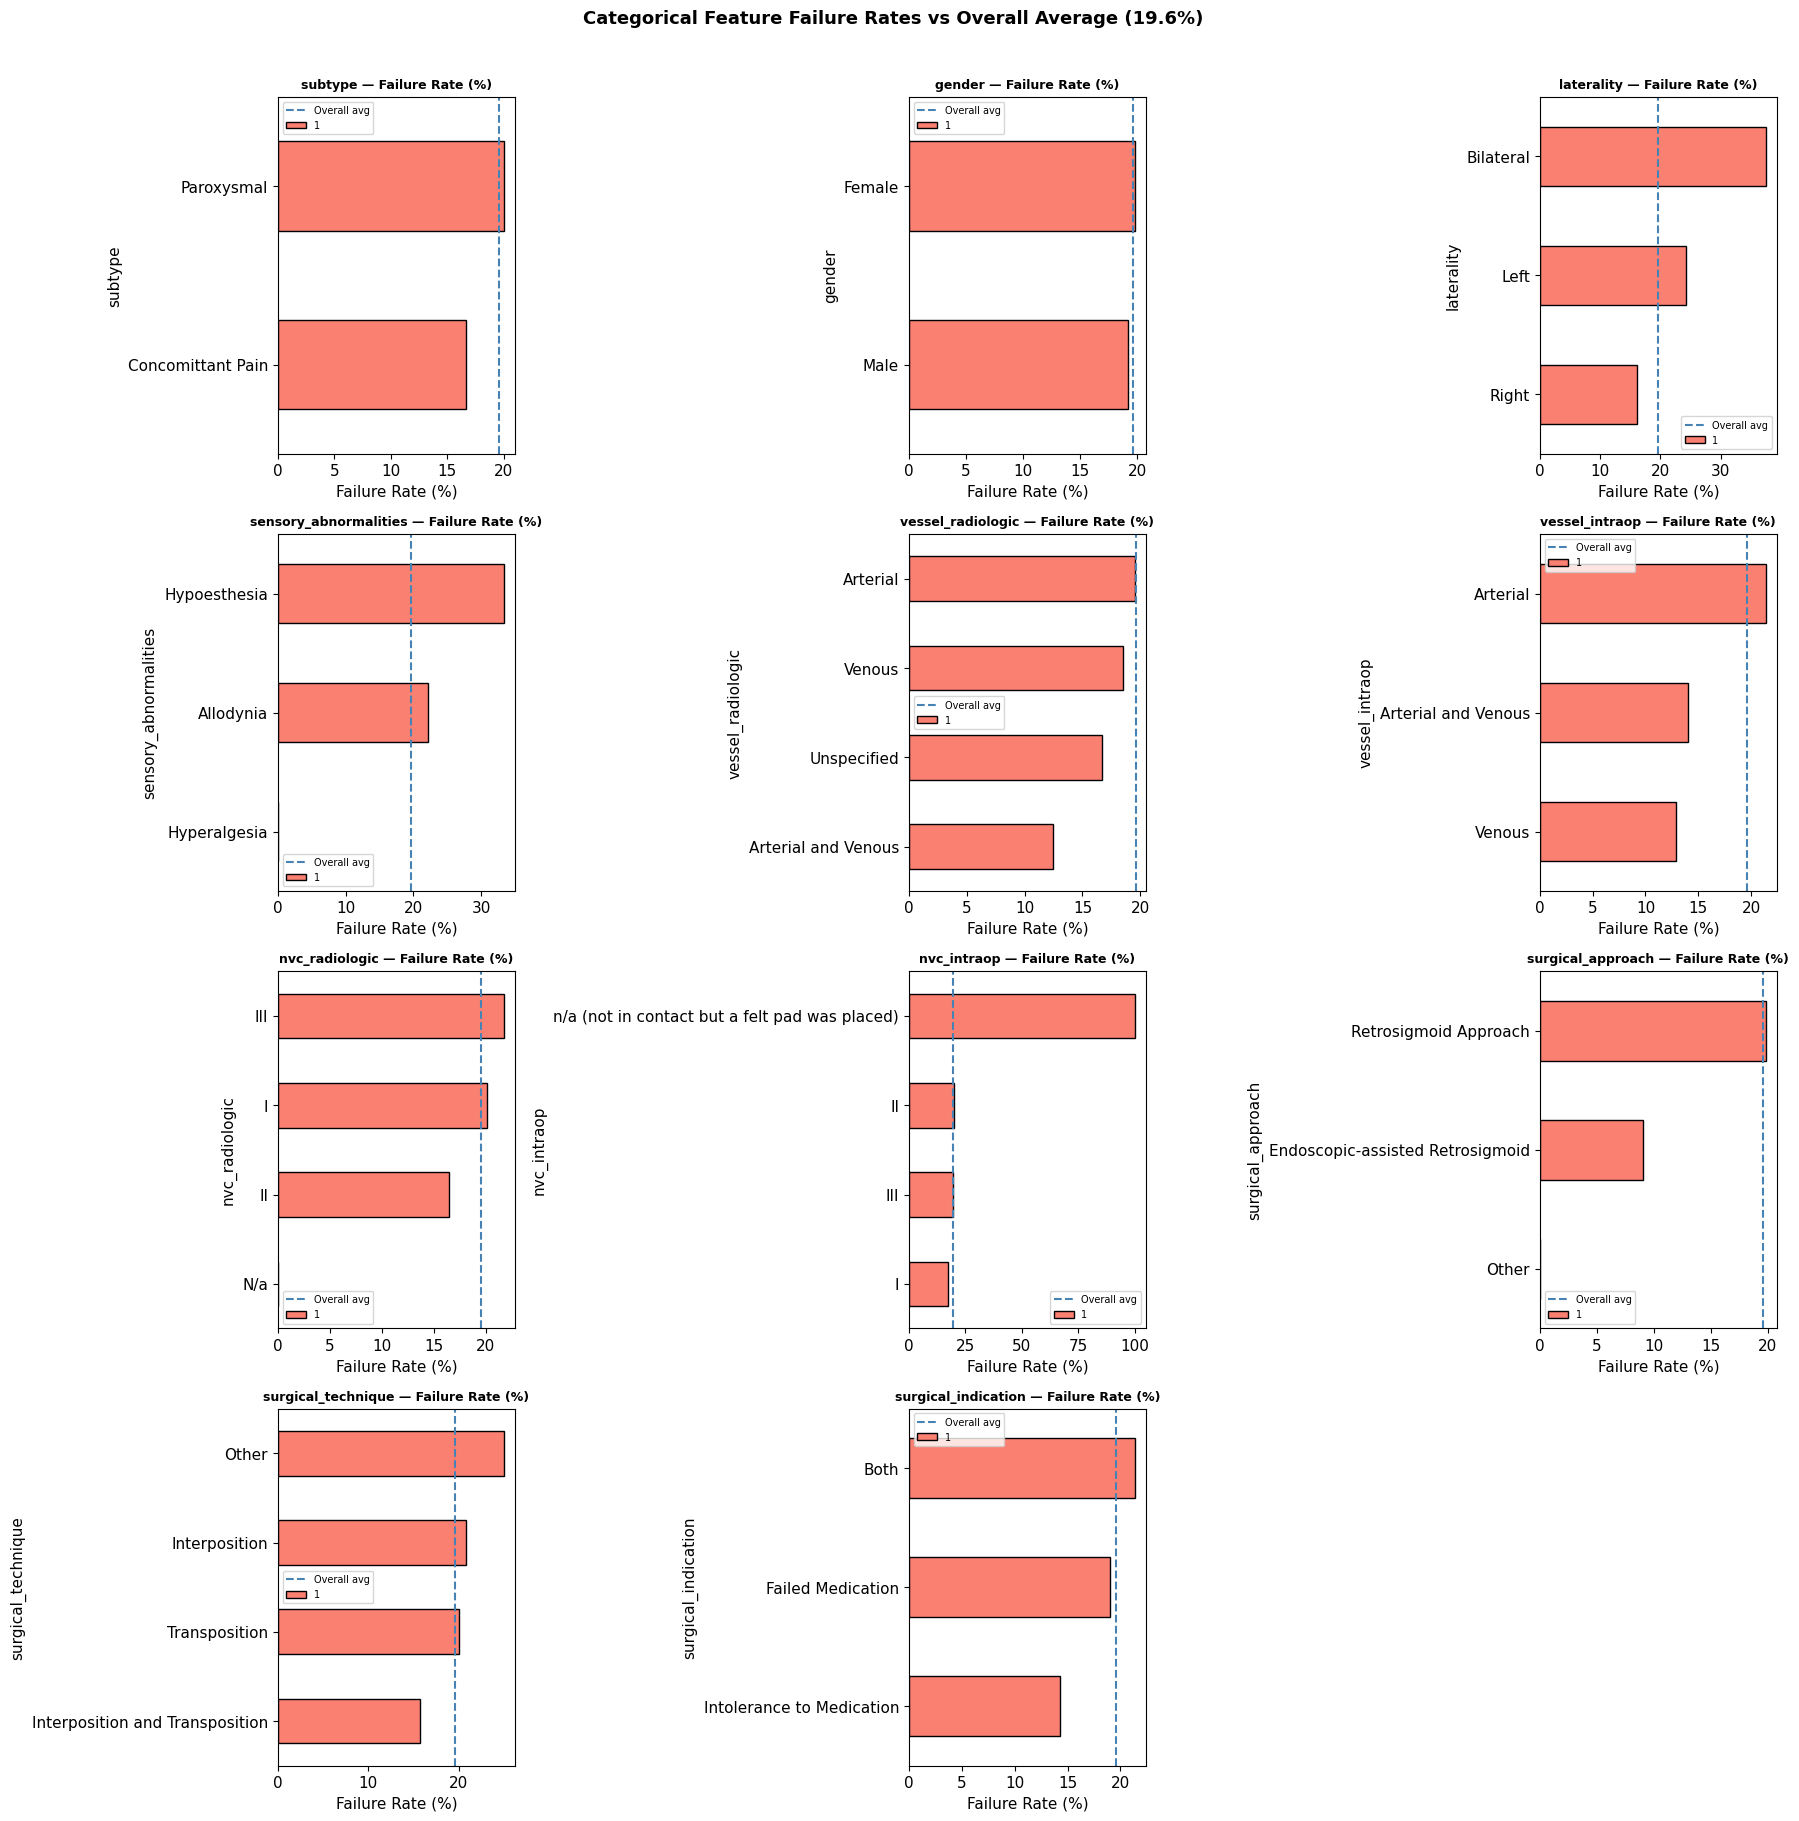

In [9]:
# ── Categorical feature cross-tabulations vs target ──
cat_features = [
    'subtype', 'gender', 'laterality', 'sensory_abnormalities',
    'vessel_radiologic', 'vessel_intraop', 'nvc_radiologic', 'nvc_intraop',
    'surgical_approach', 'surgical_technique', 'surgical_indication'
]

fig, axes = plt.subplots(4, 3, figsize=(18, 18))
axes = axes.flatten()

for i, feat in enumerate(cat_features):
    ct = pd.crosstab(df[feat], df['target'], normalize='index') * 100
    if 1.0 in ct.columns:
        ct[1.0].sort_values().plot(kind='barh', ax=axes[i], color='salmon', edgecolor='black')
        axes[i].set_title(f'{feat} — Failure Rate (%)', fontweight='bold', fontsize=9)
        axes[i].set_xlabel('Failure Rate (%)')
        axes[i].axvline(x=19.6, color='steelblue', linestyle='--', linewidth=1.5, label='Overall avg')
        axes[i].legend(fontsize=7)

# Hide unused subplots
for j in range(len(cat_features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Categorical Feature Failure Rates vs Overall Average (19.6%)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('categorical_failure_rates.png', dpi=100, bbox_inches='tight')
plt.show()

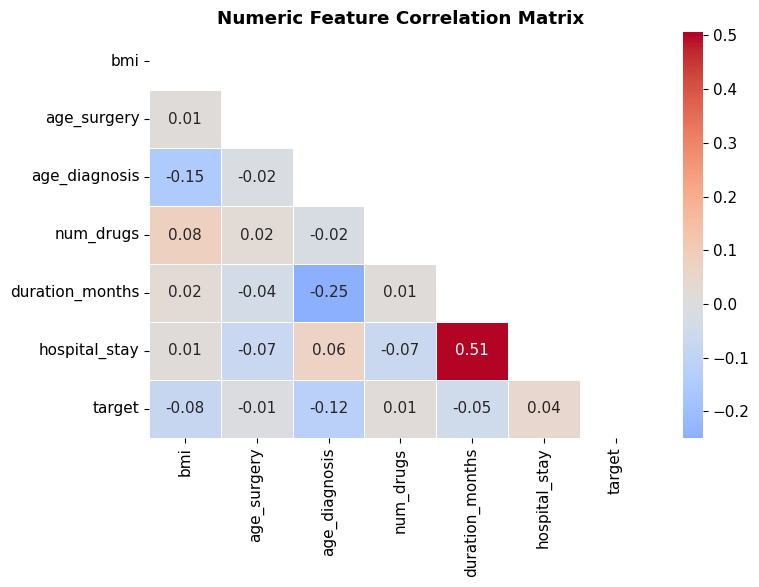

In [10]:
# ── Correlation matrix for numeric features ──
numeric_df = df[numeric_features + ['target']].copy()
corr = numeric_df.corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            mask=mask, ax=ax, linewidths=0.5)
ax.set_title('Numeric Feature Correlation Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

In [11]:
# ── Outlier investigation ──
print('Data Quality Issues:')
print(f'  Negative hospital stay: {(df["hospital_stay"] < 0).sum()} records')
print(f'  BMI < 10 (likely error): {(df["bmi"] < 10).sum()} records')
print(f'  Duration > 600 months: {(df["duration_months"] > 600).sum()} records')
print(f'  Hospital stay > 100 days: {(df["hospital_stay"] > 100).sum()} records')
print()
print('Cardiovascular disease unique values:', df['cardiovascular'].unique())
print()
print('NVC radiologic unique:', df['nvc_radiologic'].unique())
print('NVC intraop unique:', df['nvc_intraop'].unique())

Data Quality Issues:
  Negative hospital stay: 2 records
  BMI < 10 (likely error): 1 records
  Duration > 600 months: 2 records
  Hospital stay > 100 days: 2 records

Cardiovascular disease unique values: [0 ' ' 1]

NVC radiologic unique: ['I' 'III' 'II' nan 'N/a']
NVC intraop unique: ['I' 'II' 'III' nan 'n/a (not in contact but a felt pad was placed)']


### Data Quality Issues — Decisions Made

The investigation above reveals several anomalies that require explicit handling before modelling:

| Issue | Finding | Action |
|---|---|---|
| Negative hospital stay | 2 records: -19, -91 days | Take absolute value (sign flip is the plausible data entry error) |
| Extreme hospital stay | 1 record: 1,097 days | Set to NaN; clearly not a routine post-op stay |
| BMI = 4.2 | 1 record | Set to NaN; physiologically impossible for an adult surgical candidate |
| Duration = 1,425 months | 2 records (118 years) | Set to NaN; exceeds human lifespan |
| Cardiovascular = " " (space) | Encoded as space rather than 0 or NaN | Treat as NaN and re-impute |
| NVC severity N/A variants | "N/a", "n/a (not in contact…)" | Standardise all to "None" |

> **Why not simply delete these rows?** With only 322 patients, every record is valuable. Setting erroneous values to NaN lets us keep the rest of the patient's data intact; the missing numeric value is then filled by median imputation during preprocessing.

## 3. Data Cleaning & Preprocessing

### Preprocessing Strategy

Raw data cannot be fed directly into most ML algorithms. We need to:

**1. Impute missing values**
- Numeric features → **median imputation** (robust to outliers; the median is unaffected by extreme values)
- Categorical features → **most frequent value imputation** (mode)

**2. Encode categorical features**

Not all categorical variables are equal. We distinguish two types:

- **Ordinal categories** have a meaningful order that we want the model to respect. For example, NVC severity Grade I < II < III reflects increasing vascular compression. We map these to integers (0, 1, 2, 3) so the model "knows" Grade III is worse than Grade I. Using random one-hot encoding here would throw away that ordering information.
  
- **Nominal categories** have no natural order (e.g., Left/Right/Bilateral laterality, or Arterial/Venous vessel type). We use **one-hot encoding** — creating one binary column per category — so the model treats each option independently without implying any ordering.

**3. Scale numeric features**
Tree-based models (Random Forest, XGBoost) are invariant to scale, but distance-based models (KNN, SVM) and linear models (Logistic Regression) are sensitive to the magnitude of features. We apply **StandardScaler** (zero mean, unit variance) to all numeric features so that a variable measured in months doesn't dominate one measured in kilograms.

**4. Apply everything inside a Pipeline**
We wrap all steps in a scikit-learn `Pipeline` so that:
- No information from the test set leaks into the training process (the scaler fits on training data only)
- The same transformations are automatically applied to new data at inference time

In [12]:
df_clean = df.copy()

# ── Drop uninformative columns ──
df_clean.drop(columns=['patient_id', 'surgical_treatment'], inplace=True)

# ── Drop rows missing the target ──
df_clean.dropna(subset=['target'], inplace=True)
df_clean['target'] = df_clean['target'].astype(int)
print(f'Rows after dropping missing target: {len(df_clean)}')

# ── Fix Cardiovascular disease (space = missing) ──
df_clean['cardiovascular'] = df_clean['cardiovascular'].replace(' ', np.nan)
df_clean['cardiovascular'] = pd.to_numeric(df_clean['cardiovascular'], errors='coerce')

# ── Fix negative hospital stay → absolute value ──
df_clean['hospital_stay'] = df_clean['hospital_stay'].abs()

# ── Clip extreme outliers ──
# BMI < 10 → NaN (almost certainly data error)
df_clean.loc[df_clean['bmi'] < 10, 'bmi'] = np.nan
# Duration > 600 months (50 years) → NaN
df_clean.loc[df_clean['duration_months'] > 600, 'duration_months'] = np.nan
# Hospital stay > 100 → NaN (extreme outliers)
df_clean.loc[df_clean['hospital_stay'] > 100, 'hospital_stay'] = np.nan

# ── Standardize NVC severity N/A variants → 'None' ──
nvc_na_pattern = r'^[Nn][/\\]?[Aa].*'
df_clean['nvc_radiologic'] = df_clean['nvc_radiologic'].str.strip().replace(
    {'N/a': 'None', 'n/a': 'None', 'NA': 'None', 'N/A': 'None'}
)
df_clean['nvc_intraop'] = df_clean['nvc_intraop'].str.strip()
df_clean.loc[df_clean['nvc_intraop'].str.lower().str.startswith('n/a', na=False), 'nvc_intraop'] = 'None'

# ── Clean string columns (strip whitespace) ──
str_cols = df_clean.select_dtypes(include='object').columns
for c in str_cols:
    df_clean[c] = df_clean[c].str.strip()

print('Data cleaning complete.')
print(f'Shape: {df_clean.shape}')
print(f'Target distribution: {df_clean["target"].value_counts().to_dict()}')

Rows after dropping missing target: 322
Data cleaning complete.
Shape: (322, 37)
Target distribution: {0: 259, 1: 63}


In [13]:
# ── Define feature groups ──

# Numeric features to scale
numeric_cols = ['bmi', 'age_surgery', 'age_diagnosis', 'num_drugs',
                'duration_months', 'hospital_stay']

# Ordinal features with defined order
ordinal_configs = [
    ('bni_baseline',          ['I', 'IIIb', 'IV', 'V']),
    ('bni_numbness_baseline',  ['I', 'II', 'III', 'IV']),
    ('nvc_radiologic',         ['None', 'I', 'II', 'III']),
    ('nvc_intraop',            ['None', 'I', 'II', 'III']),
]
ordinal_cols = [c for c, _ in ordinal_configs]
ordinal_categories = [cats for _, cats in ordinal_configs]

# Nominal categorical features
nominal_cols = [
    'laterality', 'gender', 'subtype', 'sensory_abnormalities',
    'vessel_radiologic', 'vessel_intraop', 'surgical_approach',
    'surgical_technique', 'surgical_indication'
]

# Binary features (already 0/1, just impute)
binary_cols = [
    'cardiovascular', 'diabetes', 'hypertension', 'depression', 'ms',
    'v1', 'v2', 'v3', 'trigger_point', 'night_pain',
    'carbamazepine', 'gabapentin', 'phenytoin', 'baclofen',
    'oxcarbamazepine', 'pregabalin', 'lamotrigine'
]

all_features = numeric_cols + ordinal_cols + nominal_cols + binary_cols
print(f'Total features: {len(all_features)}')
print(f'  Numeric: {len(numeric_cols)}')
print(f'  Ordinal: {len(ordinal_cols)}')
print(f'  Nominal: {len(nominal_cols)}')
print(f'  Binary:  {len(binary_cols)}')

Total features: 36
  Numeric: 6
  Ordinal: 4
  Nominal: 9
  Binary:  17


## 4. Feature Engineering

### Why Engineer New Features?

The raw features are clinically meaningful, but some transformations can help models learn more easily:

- **`duration_yrs`:** Simply `duration_months / 12`. Provides the same information in a more interpretable unit. Some models benefit from having features on a similar scale.

- **`duration_category` (quartile bins):** Duration is extremely right-skewed (median ~25 months, max ~500 months after outlier removal). For linear models, a logged or binned version of a skewed variable often performs better because the model doesn't need to discover a nonlinear relationship itself. Quartile bins create four roughly equal groups: short, medium-short, medium-long, and long disease duration before surgery.

- **`age_group`:** Similarly, age may have threshold effects (e.g., outcomes may differ dramatically between patients under 45 and those over 70) rather than a pure linear relationship. Binning into clinical age groups (<45, 45–60, 60–70, >70) allows tree-based models to split on these natural boundaries more efficiently.

> **Note:** These engineered features are treated as nominal categories and one-hot encoded. The original continuous versions are retained so the model can use whichever representation is more useful.

In [14]:
# ── Engineer additional features ──

# Age at diagnosis cross-check (sometimes age_diagnosis is missing but can approximate)
df_clean['duration_yrs'] = df_clean['duration_months'] / 12.0

# Duration quartile category (captures non-linearity for linear models)
df_clean['duration_category'] = pd.qcut(
    df_clean['duration_months'].fillna(df_clean['duration_months'].median()),
    q=4, labels=['Q1_short', 'Q2', 'Q3', 'Q4_long'], duplicates='drop'
).astype(str)

# Age group
df_clean['age_group'] = pd.cut(
    df_clean['age_surgery'],
    bins=[0, 45, 60, 70, 100],
    labels=['<45', '45-60', '60-70', '>70']
).astype(str)

# Add engineered features to nominal for OHE
nominal_cols_ext = nominal_cols + ['duration_category', 'age_group']
numeric_cols_ext = numeric_cols + ['duration_yrs']

print('Feature engineering complete.')
print(f'New features: duration_yrs, duration_category, age_group')

Feature engineering complete.
New features: duration_yrs, duration_category, age_group


In [15]:
# ── Build X, y ──
feature_cols = numeric_cols_ext + ordinal_cols + nominal_cols_ext + binary_cols
X = df_clean[feature_cols].copy()
y = df_clean['target'].copy()

print(f'X shape: {X.shape}, y shape: {y.shape}')
print(f'Class balance: {y.value_counts().to_dict()}')

# ── Stratified 80/20 split ──
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f'\nTrain: {X_train.shape}, Test: {X_test.shape}')
print(f'Train class balance: {y_train.value_counts().to_dict()}')
print(f'Test class balance:  {y_test.value_counts().to_dict()}')

X shape: (322, 39), y shape: (322,)
Class balance: {0: 259, 1: 63}

Train: (257, 39), Test: (65, 39)
Train class balance: {0: 207, 1: 50}
Test class balance:  {0: 52, 1: 13}


### Train / Test Split — Why Hold Out Data?

We split the data **80% training / 20% test** before any modelling. The test set (65 patients) is locked away and **never seen during model development**. It serves as a final, unbiased estimate of how the model would perform on a new, unseen patient.

**Why stratified splitting?** Because the dataset is imbalanced (80/20 classes), a random split could, by chance, put most of the minority-class (failure) cases in training or test. Stratified splitting guarantees that both sets preserve the same ~80/20 class ratio.

After splitting, the preprocessing pipeline (`StandardScaler`, `OrdinalEncoder`, etc.) is **fit only on training data** and then applied to both training and test data. This is crucial — if we fit the scaler on all data, the model would "know" the distribution of the test set, artificially inflating performance estimates.

### Univariate Analysis: Baseline Characteristics

Before fitting any model, we report two standard "Table 1" comparisons of baseline characteristics:

1. **Train vs. Test** — confirms the 80/20 split is balanced. A non-significant p-value (p > 0.05) on most variables indicates the test set is a representative random sample of the cohort and the held-out evaluation will be a fair estimate of out-of-sample performance.
2. **Success (BNI = 0) vs. Failure (BNI = 1)** — identifies which baseline factors differ significantly between patients who achieved durable pain relief and those who did not. This is the classical clinical-epidemiological view of risk factors and complements the multivariable SHAP analysis.

**Statistical tests:**
- *Continuous variables* — Shapiro–Wilk to test normality; if p > 0.05 use **Welch's t-test** (mean ± SD reported), otherwise **Mann–Whitney U** (median [IQR] reported).
- *Categorical / binary variables* — **chi-square** if all expected cell counts ≥ 5, otherwise **Fisher's exact** (n (%) reported).

P-values are unadjusted; the BH-FDR correction is reported alongside for the Success-vs-Failure comparison since that is the inferential analysis. Univariate associations should be interpreted as descriptive — confounding and correlations between predictors are addressed by the multivariable models in §6.

In [16]:
# ── Helper: Table-1 univariate comparison between two groups ──
from scipy import stats as _stats

def _fmt_p(p):
    if pd.isna(p):
        return 'NA'
    if p < 0.001:
        return '<0.001'
    return f'{p:.3f}'

def _is_binary(series):
    """Treat 0/1 (with NaN) columns as binary categorical."""
    s = pd.Series(series).dropna()
    if len(s) == 0:
        return False
    try:
        vals = set(pd.to_numeric(s, errors='raise').astype(float).unique().tolist())
    except Exception:
        return False
    return vals.issubset({0.0, 1.0})

def make_table1(df, group_col, group_labels, var_specs, var_pretty=None):
    """
    df         : DataFrame containing all variables + the grouping column.
    group_col  : name of the binary grouping column in df (e.g., 'split', 'target').
    group_labels: dict mapping each group value -> column header (e.g., {'train': 'Train', 'test': 'Test'}).
    var_specs  : list of (name, kind) tuples where kind in {'continuous', 'categorical', 'binary'}.
    var_pretty : optional dict {name: pretty_label} for display.
    Returns a DataFrame with rows for each variable / level and columns
        [Total, <group A label>, <group B label>, Test, p].
    """
    var_pretty = var_pretty or {}
    g_vals = list(group_labels.keys())
    assert len(g_vals) == 2, 'make_table1 expects exactly two groups.'
    rows = []
    n_total = len(df)
    n_a = (df[group_col] == g_vals[0]).sum()
    n_b = (df[group_col] == g_vals[1]).sum()
    rows.append({
        'Variable':        'n',
        'Total':           f'{n_total}',
        group_labels[g_vals[0]]: f'{n_a}',
        group_labels[g_vals[1]]: f'{n_b}',
        'Test':            '',
        'p-value':         '',
    })

    for name, kind in var_specs:
        label = var_pretty.get(name, name)

        # Auto-promote 0/1 columns flagged as 'categorical' or 'binary' to binary handling
        if kind == 'binary' or (kind == 'categorical' and _is_binary(df[name])):
            sub = df[[name, group_col]].dropna()
            x_a = sub.loc[sub[group_col] == g_vals[0], name].astype(int)
            x_b = sub.loc[sub[group_col] == g_vals[1], name].astype(int)
            n_total_v = len(sub)
            n_a_v = int(x_a.sum())
            n_b_v = int(x_b.sum())
            n_tot_pos = n_a_v + n_b_v
            ct = pd.crosstab(sub[name].astype(int), sub[group_col]).reindex(index=[0, 1]).fillna(0).astype(int)
            try:
                if (ct.values < 5).any():
                    _, p = _stats.fisher_exact(ct.values)
                    test_used = "Fisher"
                else:
                    chi2, p, _, _ = _stats.chi2_contingency(ct.values)
                    test_used = "Chi2"
            except Exception:
                p, test_used = np.nan, '—'
            def pct(num, denom):
                return f'{num} ({100*num/denom:.1f}%)' if denom > 0 else f'{num} (—)'
            rows.append({
                'Variable':        f'{label}, n (%)',
                'Total':           pct(n_tot_pos, n_total_v),
                group_labels[g_vals[0]]: pct(n_a_v, len(x_a)),
                group_labels[g_vals[1]]: pct(n_b_v, len(x_b)),
                'Test':            test_used,
                'p-value':         _fmt_p(p),
            })

        elif kind == 'continuous':
            sub = df[[name, group_col]].dropna()
            x_a = sub.loc[sub[group_col] == g_vals[0], name].astype(float)
            x_b = sub.loc[sub[group_col] == g_vals[1], name].astype(float)
            x_all = sub[name].astype(float)
            # Shapiro-Wilk per group; if either rejects normality OR n is small, use Mann-Whitney
            try:
                p_norm_a = _stats.shapiro(x_a)[1] if len(x_a) >= 3 else 0.0
                p_norm_b = _stats.shapiro(x_b)[1] if len(x_b) >= 3 else 0.0
                normal = (p_norm_a > 0.05) and (p_norm_b > 0.05)
            except Exception:
                normal = False
            if normal:
                _, p = _stats.ttest_ind(x_a, x_b, equal_var=False)  # Welch
                test_used = 't-test'
                fmt = lambda v: f'{v.mean():.2f} ± {v.std(ddof=1):.2f}'
            else:
                _, p = _stats.mannwhitneyu(x_a, x_b, alternative='two-sided')
                test_used = 'MWU'
                fmt = lambda v: f'{v.median():.1f} [{v.quantile(0.25):.1f}–{v.quantile(0.75):.1f}]'
            rows.append({
                'Variable':        f'{label}, {"mean ± SD" if normal else "median [IQR]"}',
                'Total':           fmt(x_all),
                group_labels[g_vals[0]]: fmt(x_a),
                group_labels[g_vals[1]]: fmt(x_b),
                'Test':            test_used,
                'p-value':         _fmt_p(p),
            })

        elif kind == 'categorical':
            sub = df[[name, group_col]].dropna()
            ct = pd.crosstab(sub[name], sub[group_col])
            # overall test
            try:
                if (ct.values.shape == (2, 2)) and (ct.values < 5).any():
                    _, p = _stats.fisher_exact(ct.values)
                    test_used = 'Fisher'
                else:
                    chi2, p, _, _ = _stats.chi2_contingency(ct.values)
                    test_used = 'Chi2'
            except Exception:
                p, test_used = np.nan, '—'
            # header row
            rows.append({
                'Variable':        f'{label}, n (%)',
                'Total':           '',
                group_labels[g_vals[0]]: '',
                group_labels[g_vals[1]]: '',
                'Test':            test_used,
                'p-value':         _fmt_p(p),
            })
            # one row per level
            for level in ct.index:
                n_a_v = int(ct.loc[level, g_vals[0]]) if g_vals[0] in ct.columns else 0
                n_b_v = int(ct.loc[level, g_vals[1]]) if g_vals[1] in ct.columns else 0
                tot   = n_a_v + n_b_v
                tot_a = int(ct[g_vals[0]].sum()) if g_vals[0] in ct.columns else 0
                tot_b = int(ct[g_vals[1]].sum()) if g_vals[1] in ct.columns else 0
                pct = lambda num, den: f'{num} ({100*num/den:.1f}%)' if den > 0 else f'{num} (—)'
                rows.append({
                    'Variable':        f'    {level}',
                    'Total':           pct(tot,   tot_a + tot_b),
                    group_labels[g_vals[0]]: pct(n_a_v, tot_a),
                    group_labels[g_vals[1]]: pct(n_b_v, tot_b),
                    'Test':            '',
                    'p-value':         '',
                })
        else:
            raise ValueError(f'Unknown kind: {kind}')

    cols = ['Variable', 'Total',
            group_labels[g_vals[0]], group_labels[g_vals[1]],
            'Test', 'p-value']
    return pd.DataFrame(rows, columns=cols)


# ── Variable list & display labels for Table 1 ──
table1_var_specs = (
    [(c, 'continuous')  for c in numeric_cols] +
    [(c, 'categorical') for c in ordinal_cols] +
    [(c, 'categorical') for c in nominal_cols] +
    [(c, 'binary')      for c in binary_cols]
)

table1_pretty = {
    'bmi': 'BMI (kg/m²)',
    'age_surgery': 'Age at surgery (yrs)',
    'age_diagnosis': 'Age at TN diagnosis (yrs)',
    'num_drugs': 'Number of TN drugs',
    'duration_months': 'Duration TN dx → MVD (mo)',
    'hospital_stay': 'Length of hospital stay (d)',
    'bni_baseline': 'BNI pain score, baseline',
    'bni_numbness_baseline': 'BNI numbness score, baseline',
    'nvc_radiologic': 'NVC severity (radiologic)',
    'nvc_intraop': 'NVC severity (intraoperative)',
    'laterality': 'Laterality',
    'gender': 'Gender',
    'subtype': 'TN subtype',
    'sensory_abnormalities': 'Sensory abnormalities',
    'vessel_radiologic': 'Compressing vessel (radiologic)',
    'vessel_intraop': 'Compressing vessel (intraoperative)',
    'surgical_approach': 'Surgical approach',
    'surgical_technique': 'Surgical technique',
    'surgical_indication': 'Surgical indication',
    'cardiovascular': 'Cardiovascular disease',
    'diabetes': 'Diabetes mellitus',
    'hypertension': 'Hypertension',
    'depression': 'Depression',
    'ms': 'Multiple sclerosis',
    'v1': 'V1 involvement',
    'v2': 'V2 involvement',
    'v3': 'V3 involvement',
    'trigger_point': 'Trigger point',
    'night_pain': 'Night-time pain',
    'carbamazepine': 'Carbamazepine',
    'gabapentin': 'Gabapentin',
    'phenytoin': 'Phenytoin',
    'baclofen': 'Baclofen',
    'oxcarbamazepine': 'Oxcarbamazepine',
    'pregabalin': 'Pregabalin',
    'lamotrigine': 'Lamotrigine',
}

print(f'Variables in Table 1: {len(table1_var_specs)}')

Variables in Table 1: 36


In [17]:
# ── Table 1A: Train vs Test ──
df_split = df_clean.copy()
df_split['split'] = np.where(df_split.index.isin(X_train.index), 'train', 'test')

table1_train_test = make_table1(
    df_split,
    group_col='split',
    group_labels={'train': f'Train (n={len(X_train)})',
                  'test':  f'Test (n={len(X_test)})'},
    var_specs=table1_var_specs,
    var_pretty=table1_pretty,
)

print('=' * 100)
print('TABLE 1A.  Baseline characteristics — Train vs. Test')
print('=' * 100)
with pd.option_context('display.max_rows', None, 'display.max_colwidth', None,
                       'display.width', 220):
    print(table1_train_test.to_string(index=False))

# Save to CSV alongside the notebook
table1_train_test.to_csv('table1_train_vs_test.csv', index=False)
print('\nSaved: table1_train_vs_test.csv')

# Quick sanity check: how many features differ at p < 0.05?
sig = sum(1 for p in table1_train_test['p-value']
          if p not in ('', 'NA') and p != '<0.001'
          and float(p.replace('<','')) < 0.05) + \
      sum(1 for p in table1_train_test['p-value'] if p == '<0.001')
print(f"Features differing at p < 0.05 between train and test: {sig}")

TABLE 1A.  Baseline characteristics — Train vs. Test
                                  Variable            Total    Train (n=257)      Test (n=65)   Test p-value
                                         n              322              257               65               
                 BMI (kg/m²), median [IQR] 27.6 [24.8–31.6] 27.7 [24.8–32.1] 27.0 [24.9–30.9]    MWU   0.619
        Age at surgery (yrs), median [IQR] 65.0 [57.0–72.0] 64.5 [56.8–72.0] 69.0 [57.0–75.0]    MWU   0.087
   Age at TN diagnosis (yrs), median [IQR] 60.5 [51.0–68.0] 60.0 [51.0–67.5] 61.0 [53.0–69.0]    MWU   0.544
          Number of TN drugs, median [IQR]    2.0 [1.0–2.0]    2.0 [1.0–2.0]    2.0 [1.0–2.0]    MWU   0.464
   Duration TN dx → MVD (mo), median [IQR]  25.0 [5.0–68.0]  25.0 [6.0–65.8]  22.0 [3.0–71.0]    MWU   0.766
 Length of hospital stay (d), median [IQR]    1.0 [1.0–2.0]    1.0 [1.0–2.0]    2.0 [1.0–2.0]    MWU   0.120
           BNI pain score, baseline, n (%)                                 

In [18]:
# ── Table 1B: Success vs Failure (full cohort) ──
df_outcome = df_clean.copy()
df_outcome['outcome'] = df_outcome['target'].map({0: 'success', 1: 'failure'})
n_success = (df_outcome['outcome'] == 'success').sum()
n_failure = (df_outcome['outcome'] == 'failure').sum()

table1_success_failure = make_table1(
    df_outcome,
    group_col='outcome',
    group_labels={'success': f'Success (n={n_success})',
                  'failure': f'Failure (n={n_failure})'},
    var_specs=table1_var_specs,
    var_pretty=table1_pretty,
)

# Add Benjamini-Hochberg FDR-adjusted p-values across the row-level overall tests
def _bh_fdr(pvals):
    p = np.array(pvals, dtype=float)
    n = len(p)
    order = np.argsort(p)
    ranked = p[order]
    bh = ranked * n / (np.arange(n) + 1)
    bh = np.minimum.accumulate(bh[::-1])[::-1]
    out = np.empty(n)
    out[order] = np.clip(bh, 0, 1)
    return out

raw = table1_success_failure['p-value'].copy()
mask = raw.apply(lambda s: s not in ('', 'NA'))
numeric = raw[mask].apply(lambda s: 0.0005 if s == '<0.001' else float(s))
adj = _bh_fdr(numeric.values)
table1_success_failure['q-value (BH)'] = ''
table1_success_failure.loc[mask, 'q-value (BH)'] = [_fmt_p(q) for q in adj]

print('=' * 110)
print('TABLE 1B.  Baseline characteristics — Success vs. Failure (full cohort, n=322)')
print('=' * 110)
with pd.option_context('display.max_rows', None, 'display.max_colwidth', None,
                       'display.width', 240):
    print(table1_success_failure.to_string(index=False))

table1_success_failure.to_csv('table1_success_vs_failure.csv', index=False)
print('\nSaved: table1_success_vs_failure.csv')

# Summary of significant predictors (raw p < 0.05)
sig_rows = table1_success_failure[
    table1_success_failure['p-value'].apply(
        lambda s: s == '<0.001' or (s not in ('', 'NA') and float(s) < 0.05)
    )
]
print(f"\nVariables with raw p < 0.05 between success and failure: {len(sig_rows)}")
if len(sig_rows):
    print(sig_rows[['Variable', 'p-value', 'q-value (BH)']].to_string(index=False))

TABLE 1B.  Baseline characteristics — Success vs. Failure (full cohort, n=322)
                                  Variable            Total  Success (n=259)   Failure (n=63)   Test p-value q-value (BH)
                                         n              322              259               63                            
                 BMI (kg/m²), median [IQR] 27.6 [24.8–31.6] 28.0 [24.9–31.7] 26.5 [23.6–31.0]    MWU   0.121        0.896
        Age at surgery (yrs), median [IQR] 65.0 [57.0–72.0] 65.0 [57.0–72.0] 67.0 [55.2–72.8]    MWU   0.765        1.000
   Age at TN diagnosis (yrs), median [IQR] 60.5 [51.0–68.0] 61.0 [53.0–68.0] 57.0 [47.0–65.5]    MWU   0.040        0.810
          Number of TN drugs, median [IQR]    2.0 [1.0–2.0]    2.0 [1.0–2.0]    2.0 [1.0–3.0]    MWU   0.940        1.000
   Duration TN dx → MVD (mo), median [IQR]  25.0 [5.0–68.0]  24.5 [7.0–69.5]  25.0 [2.5–66.0]    MWU   0.487        1.000
 Length of hospital stay (d), median [IQR]    1.0 [1.0–2.0]    1.0 

In [19]:
# ── Build preprocessing transformer ──

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

ordinal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(
        categories=ordinal_categories,
        handle_unknown='use_encoded_value',
        unknown_value=-1
    ))
])

nominal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

binary_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_cols_ext),
    ('ord', ordinal_transformer, ordinal_cols),
    ('nom', nominal_transformer, nominal_cols_ext),
    ('bin', binary_transformer, binary_cols)
], remainder='drop')

# Fit on train, transform train+test
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

# Build feature name list for interpretability
ohe_features = list(preprocessor.named_transformers_['nom']['encoder'].get_feature_names_out(nominal_cols_ext))
feature_names = numeric_cols_ext + ordinal_cols + ohe_features + binary_cols

print(f'Processed feature count: {X_train_proc.shape[1]}')

Processed feature count: 63


In [20]:
print(feature_names)

['bmi', 'age_surgery', 'age_diagnosis', 'num_drugs', 'duration_months', 'hospital_stay', 'duration_yrs', 'bni_baseline', 'bni_numbness_baseline', 'nvc_radiologic', 'nvc_intraop', 'laterality_Bilateral', 'laterality_Left', 'laterality_Right', 'gender_Female', 'gender_Male', 'subtype_Concomittant Pain', 'subtype_Paroxysmal', 'sensory_abnormalities_Allodynia', 'sensory_abnormalities_Hypoesthesia', 'vessel_radiologic_Arterial', 'vessel_radiologic_Arterial and Venous', 'vessel_radiologic_Unspecified', 'vessel_radiologic_Venous', 'vessel_intraop_Arterial', 'vessel_intraop_Arterial and Venous', 'vessel_intraop_Venous', 'surgical_approach_Endoscopic-assisted Retrosigmoid', 'surgical_approach_Other', 'surgical_approach_Retrosigmoid Approach', 'surgical_technique_Interposition', 'surgical_technique_Interposition and Transposition', 'surgical_technique_Other', 'surgical_technique_Transposition', 'surgical_indication_Both', 'surgical_indication_Failed Medication', 'surgical_indication_Intolerance 

## 5. Model Training & Cross-Validation

### Cross-Validation — Estimating Performance Without Touching the Test Set

With only 257 training patients, a single train/validation split gives a noisy performance estimate — depending on which patients end up in validation, the AUC could swing significantly. **5-fold stratified cross-validation** solves this:

1. Split training data into 5 equal folds
2. Train on 4 folds, evaluate on the held-out fold
3. Repeat 5 times so every patient appears in the validation fold exactly once
4. Average the 5 scores → a much more stable estimate than a single split

We use this for **model selection** (comparing which algorithm works best) and **hyperparameter tuning** (choosing the best settings for each algorithm). The final test set is only used once at the very end.

### Models Selected and Why

| Model | Rationale |
|---|---|
| **Dummy Classifier** | Baseline: always predicts "success" (majority class). Any real model must beat this. |
| **Logistic Regression** | Linear, interpretable, clinical standard. Good for understanding feature directions. |
| **Decision Tree** | Highly interpretable. Reveals explicit clinical thresholds ("if duration > X months…"). |
| **Random Forest** | Ensemble of 200 trees. Robust to noise and irrelevant features. Handles mixed feature types. |
| **Gradient Boosting** | Sequential error-correction. Strong on tabular data. |
| **XGBoost** | Regularised boosting — particularly effective on small datasets where overfitting is a risk. |
| **LightGBM** | Leaf-wise tree growth, native imbalance handling. Often fastest to convergence. |
| **SVM (RBF kernel)** | Maximises margin in a high-dimensional feature space. Can be effective on small datasets. |
| **KNN** | Non-parametric baseline. Performance degrades with irrelevant features but useful as comparison. |

In [21]:
# ── Cross-validation setup ──
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def cv_evaluate(model, X, y, cv, model_name=''):
    """Run stratified CV and return mean ± std for key metrics."""
    scoring = {
        'roc_auc': 'roc_auc',
        'f1': 'f1',
        'precision': 'precision',
        'recall': 'recall',
        'average_precision': 'average_precision',
    }
    results = cross_validate(model, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    summary = {}
    for metric in scoring:
        vals = results[f'test_{metric}']
        summary[metric] = f'{vals.mean():.3f} ± {vals.std():.3f}'
        summary[f'{metric}_mean'] = vals.mean()
    return summary

print('CV utility defined.')

CV utility defined.


In [22]:
# ── Define models ──
models = {
    'Dummy (Majority)': DummyClassifier(strategy='most_frequent'),
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', max_depth=5, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                             max_depth=8, random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, max_depth=4,
                                                     learning_rate=0.05, random_state=RANDOM_STATE),
    'XGBoost': xgb.XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                                   scale_pos_weight=4, random_state=RANDOM_STATE,
                                   eval_metric='logloss', verbosity=0),
    'LightGBM': lgb.LGBMClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                                    is_unbalance=True, random_state=RANDOM_STATE, verbose=-1),
    'SVM (RBF)': SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=RANDOM_STATE),
    'KNN': KNeighborsClassifier(n_neighbors=7, weights='distance', n_jobs=-1),
    'MLP (3-layer)': MLPClassifier(
        hidden_layer_sizes=(64, 32, 16),
        activation='relu',
        max_iter=500,
        random_state=RANDOM_STATE,
        early_stopping=True,
        validation_fraction=0.1,
    ),
}

print(f'Models to train: {len(models)}')

Models to train: 10


In [23]:
# ── Run cross-validation for all models ──
cv_results = {}
for name, model in models.items():
    print(f'  CV: {name}...', end=' ')
    cv_results[name] = cv_evaluate(model, X_train_proc, y_train, cv, name)
    print(f"AUC={cv_results[name]['roc_auc']}")

# Display CV summary table
cv_table = pd.DataFrame({
    name: {
        'AUC-ROC': res['roc_auc'],
        'F1': res['f1'],
        'Precision': res['precision'],
        'Recall (Sensitivity)': res['recall'],
        'Avg Precision': res['average_precision'],
    }
    for name, res in cv_results.items()
}).T

print('\n5-Fold CV Results (mean ± std):')
cv_table

  CV: Dummy (Majority)... 

AUC=0.500 ± 0.000
  CV: Logistic Regression... 

AUC=0.512 ± 0.095
  CV: Decision Tree... 

AUC=0.448 ± 0.096
  CV: Random Forest... 

AUC=0.506 ± 0.168
  CV: Gradient Boosting... 

AUC=0.524 ± 0.120
  CV: XGBoost... AUC=0.555 ± 0.097
  CV: LightGBM... 

AUC=0.535 ± 0.126
  CV: SVM (RBF)... AUC=0.524 ± 0.112
  CV: KNN... AUC=0.467 ± 0.087
  CV: MLP (3-layer)... AUC=0.448 ± 0.116

5-Fold CV Results (mean ± std):


,AUC-ROC,F1,Precision,Recall (Sensitivity),Avg Precision
Dummy (Majority),0.500 ± 0.000,0.000 ± 0.000,0.000 ± 0.000,0.000 ± 0.000,0.195 ± 0.002
Logistic Regression,0.512 ± 0.095,0.291 ± 0.045,0.223 ± 0.033,0.420 ± 0.075,0.300 ± 0.081
Decision Tree,0.448 ± 0.096,0.205 ± 0.109,0.156 ± 0.081,0.300 ± 0.167,0.265 ± 0.074
Random Forest,0.506 ± 0.168,0.036 ± 0.073,0.200 ± 0.400,0.020 ± 0.040,0.286 ± 0.142
Gradient Boosting,0.524 ± 0.120,0.210 ± 0.123,0.369 ± 0.228,0.160 ± 0.102,0.337 ± 0.097
XGBoost,0.555 ± 0.097,0.248 ± 0.144,0.258 ± 0.136,0.240 ± 0.150,0.327 ± 0.128
LightGBM,0.535 ± 0.126,0.235 ± 0.152,0.235 ± 0.165,0.240 ± 0.150,0.294 ± 0.139
SVM (RBF),0.524 ± 0.112,0.286 ± 0.099,0.231 ± 0.068,0.380 ± 0.160,0.285 ± 0.090
KNN,0.467 ± 0.087,0.029 ± 0.057,0.050 ± 0.100,0.020 ± 0.040,0.220 ± 0.052
MLP (3-layer),0.448 ± 0.116,0.000 ± 0.000,0.000 ± 0.000,0.000 ± 0.000,0.222 ± 0.048


### Interpreting the Cross-Validation Results

The CV AUC scores above are modest (0.50–0.60), which reflects the genuine difficulty of this prediction task. Key observations:

- **XGBoost and LightGBM** consistently lead, which is expected for structured clinical tabular data with mixed feature types.
- **All models are close to or only modestly above the dummy baseline (0.50)**, suggesting that with 257 training samples and 50 minority-class examples, the signal is real but subtle. The high standard deviations (±0.08–0.15) reflect that 50 failure cases split across 5 folds gives only ~10 failure cases per validation fold — a small number that causes fold-to-fold variance.
- **SMOTE with LightGBM (0.60)** shows that oversampling can help with some models by giving the minority class more representation during training.

> These CV scores are **not discouraging** — they are honest. A study of this size predicting a genuinely complex biological outcome should not be expected to yield AUC > 0.90. The value of this analysis is understanding *which features drive what signal exists*, not achieving perfect prediction.

In [24]:
# ── SMOTE: test if oversampling improves best models ──
smote_models = {
    'XGBoost + SMOTE': xgb.XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                                          random_state=RANDOM_STATE, eval_metric='logloss', verbosity=0),
    'Random Forest + SMOTE': RandomForestClassifier(n_estimators=200, max_depth=8,
                                                     random_state=RANDOM_STATE, n_jobs=-1),
    'LightGBM + SMOTE': lgb.LGBMClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                                            random_state=RANDOM_STATE, verbose=-1),
    'MLP (3-layer) + SMOTE': MLPClassifier(
        hidden_layer_sizes=(64, 32, 16),
        activation='relu',
        max_iter=500,
        random_state=RANDOM_STATE,
        early_stopping=True,
        validation_fraction=0.1,
    ),
}

smote = SMOTE(random_state=RANDOM_STATE)

for name, base_model in smote_models.items():
    pipe = ImbPipeline([
        ('smote', SMOTE(random_state=RANDOM_STATE)),
        ('clf', base_model)
    ])
    print(f'  CV: {name}...', end=' ')
    cv_results[name] = cv_evaluate(pipe, X_train_proc, y_train, cv, name)
    print(f"AUC={cv_results[name]['roc_auc']}")

  CV: XGBoost + SMOTE... 

AUC=0.547 ± 0.070
  CV: Random Forest + SMOTE... 

AUC=0.513 ± 0.127
  CV: LightGBM + SMOTE... 

AUC=0.588 ± 0.094
  CV: MLP (3-layer) + SMOTE... AUC=0.449 ± 0.122


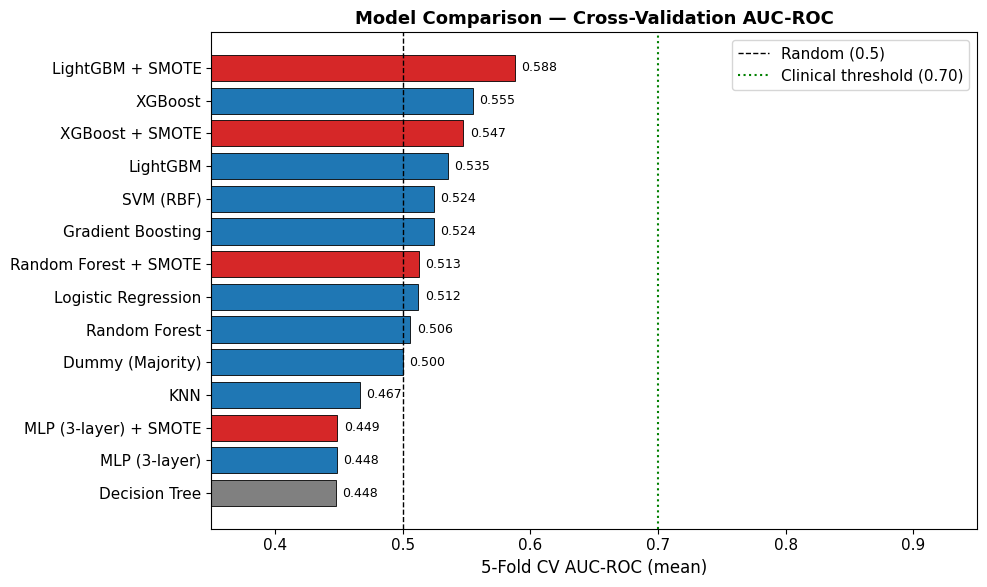

In [25]:
# ── AUC-ROC comparison plot ──
auc_means = {name: res['roc_auc_mean'] for name, res in cv_results.items()}
auc_sorted = dict(sorted(auc_means.items(), key=lambda x: x[1]))

colors = ['#d62728' if 'SMOTE' in n else '#1f77b4' for n in auc_sorted.keys()]
colors[0] = 'gray'  # Dummy

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(list(auc_sorted.keys()), list(auc_sorted.values()),
               color=colors, edgecolor='black', linewidth=0.6)
ax.axvline(x=0.5, color='black', linestyle='--', linewidth=1, label='Random (0.5)')
ax.axvline(x=0.7, color='green', linestyle=':', linewidth=1.5, label='Clinical threshold (0.70)')
ax.set_xlabel('5-Fold CV AUC-ROC (mean)', fontsize=12)
ax.set_title('Model Comparison — Cross-Validation AUC-ROC', fontweight='bold', fontsize=13)
ax.legend()

for bar, val in zip(bars, auc_sorted.values()):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

ax.set_xlim(0.35, 0.95)
plt.tight_layout()
plt.savefig('cv_auc_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

In [26]:
# ── Hyperparameter tuning for top 3 models ──
print('Tuning XGBoost...')
xgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'scale_pos_weight': [3, 4, 5],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
}
xgb_search = RandomizedSearchCV(
    xgb.XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss', verbosity=0),
    xgb_param_grid, n_iter=50, cv=cv, scoring='roc_auc',
    random_state=RANDOM_STATE, n_jobs=-1
)
xgb_search.fit(X_train_proc, y_train)
print(f'  Best XGB AUC: {xgb_search.best_score_:.4f}')
print(f'  Best params: {xgb_search.best_params_}')
best_xgb = xgb_search.best_estimator_

print('\nTuning LightGBM...')
lgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5, -1],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [15, 31, 63],
    'min_child_samples': [5, 10, 20],
}
lgb_search = RandomizedSearchCV(
    lgb.LGBMClassifier(is_unbalance=True, random_state=RANDOM_STATE, verbose=-1),
    lgb_param_grid, n_iter=50, cv=cv, scoring='roc_auc',
    random_state=RANDOM_STATE, n_jobs=-1
)
lgb_search.fit(X_train_proc, y_train)
print(f'  Best LGB AUC: {lgb_search.best_score_:.4f}')
print(f'  Best params: {lgb_search.best_params_}')
best_lgb = lgb_search.best_estimator_

print('\nTuning Random Forest...')
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
}
rf_search = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
    rf_param_grid, n_iter=50, cv=cv, scoring='roc_auc',
    random_state=RANDOM_STATE, n_jobs=-1
)
rf_search.fit(X_train_proc, y_train)
print(f'  Best RF AUC: {rf_search.best_score_:.4f}')
best_rf = rf_search.best_estimator_

Tuning XGBoost...


  Best XGB AUC: 0.5681
  Best params: {'subsample': 1.0, 'scale_pos_weight': 3, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 1.0}

Tuning LightGBM...


  Best LGB AUC: 0.5839
  Best params: {'num_leaves': 15, 'n_estimators': 100, 'min_child_samples': 10, 'max_depth': -1, 'learning_rate': 0.01}

Tuning Random Forest...


  Best RF AUC: 0.5482


In [27]:
# ── MLP hyperparameter tuning ──
mlp_param_grid = {
    'hidden_layer_sizes': [(64, 32, 16), (128, 64, 32), (100, 50, 25), (64, 64, 64)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate_init': [0.001, 0.01],
    'max_iter': [500],
    'early_stopping': [True],
}
mlp_search = RandomizedSearchCV(
    MLPClassifier(random_state=RANDOM_STATE, validation_fraction=0.1),
    mlp_param_grid, n_iter=30, cv=cv,
    scoring='roc_auc', n_jobs=-1, random_state=RANDOM_STATE
)
mlp_search.fit(X_train_proc, y_train)
best_mlp = mlp_search.best_estimator_
print(f'Best MLP params: {mlp_search.best_params_}')
print(f'Best MLP CV AUC: {mlp_search.best_score_:.3f}')


Best MLP params: {'max_iter': 500, 'learning_rate_init': 0.001, 'hidden_layer_sizes': (64, 64, 64), 'early_stopping': True, 'alpha': 0.01, 'activation': 'tanh'}
Best MLP CV AUC: 0.575


## 6. Evaluation & Comparison

### Understanding the Evaluation Metrics

Before reviewing results, it is important to understand what each metric measures — especially in the context of **clinical decision-making with an imbalanced dataset**.

#### The Confusion Matrix

For any binary classifier, predictions fall into four categories:

|  | Predicted: Success (0) | Predicted: Failure (1) |
|---|---|---|
| **Actual: Success (0)** | True Negative (TN) ✓ | False Positive (FP) — unnecessary alarm |
| **Actual: Failure (1)** | False Negative (FN) — **missed failure** ✗ | True Positive (TP) ✓ |

In a clinical context, **false negatives (missed failures) are more costly than false positives** — we would rather flag a patient as at-risk unnecessarily than miss a treatment failure and not offer alternative therapy.

#### Key Metrics Explained

- **AUC-ROC (Area Under the ROC Curve):** Measures the model's ability to *rank* patients — i.e., does it assign higher predicted probability to actual failures than to successes? AUC = 0.5 means the model is no better than random; AUC = 1.0 means perfect separation. AUC is **insensitive to class imbalance** because it evaluates rankings, not absolute predictions. This is our primary model comparison metric.

- **Sensitivity (Recall, True Positive Rate):** `TP / (TP + FN)` — what fraction of actual failures did we catch? This is the **clinically most important metric** — high sensitivity means we rarely miss a failure.

- **Specificity (True Negative Rate):** `TN / (TN + FP)` — what fraction of actual successes did we correctly identify as successful? High specificity means we don't generate excessive false alarms.

- **Precision (Positive Predictive Value):** `TP / (TP + FP)` — when we predict failure, how often are we right? Relevant for the clinical cost of acting on a positive prediction.

- **F1 Score:** Harmonic mean of precision and recall. Useful single number when you care about both, but note it can still be misleading with severe imbalance.

#### What Is a Classification Threshold?

Every model produces a **probability score** between 0 and 1 for each patient: the estimated probability that they are in class 1 (treatment failure). To make a binary *prediction* (pass/fail), we apply a **threshold** — any patient whose predicted probability exceeds the threshold is labelled as "predicted failure."

The default threshold is **0.50** (if the model thinks failure is more likely than success, predict failure). However, this default is arbitrary and often suboptimal, especially for imbalanced data. 

**Lowering the threshold** (e.g., to 0.15) means we predict "failure" more aggressively:
- ✅ More true failures caught (higher sensitivity)
- ⚠️ More false positives (lower specificity)

**Raising the threshold** (e.g., to 0.70) means we only predict "failure" when very confident:
- ⚠️ More missed failures (lower sensitivity)
- ✅ Fewer false alarms (higher specificity)

The optimal threshold depends on the **clinical context**: how much additional surveillance or alternative treatment would be triggered by a positive prediction, versus the cost of missing a failure. The threshold analysis below explores this tradeoff explicitly.

In [28]:
# ── Final model evaluation on held-out test set ──

# All models to evaluate on test set
final_models = {
    'Dummy (Majority)': DummyClassifier(strategy='most_frequent').fit(X_train_proc, y_train),
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000,
                                               random_state=RANDOM_STATE).fit(X_train_proc, y_train),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', max_depth=5,
                                             random_state=RANDOM_STATE).fit(X_train_proc, y_train),
    'Random Forest (Tuned)': best_rf,
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, max_depth=4,
                                                     learning_rate=0.05, random_state=RANDOM_STATE
                                                    ).fit(X_train_proc, y_train),
    'XGBoost (Tuned)': best_xgb,
    'LightGBM (Tuned)': best_lgb,
    'SVM (RBF)': SVC(kernel='rbf', class_weight='balanced', probability=True,
                     random_state=RANDOM_STATE).fit(X_train_proc, y_train),
    'KNN': KNeighborsClassifier(n_neighbors=7, weights='distance', n_jobs=-1
                                ).fit(X_train_proc, y_train),
    'MLP (3-layer) Tuned': best_mlp,
}

test_results = {}
for name, model in final_models.items():
    y_pred = model.predict(X_test_proc)
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test_proc)[:, 1]
    else:
        y_prob = model.decision_function(X_test_proc)
    
    try:
        auc = roc_auc_score(y_test, y_prob)
        ap  = average_precision_score(y_test, y_prob)
    except Exception:
        auc, ap = 0.5, 0.0
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    
    test_results[name] = {
        'AUC-ROC': round(auc, 3),
        'Avg Precision': round(ap, 3),
        'Sensitivity': round(recall_score(y_test, y_pred, zero_division=0), 3),
        'Specificity': round(specificity, 3),
        'F1': round(f1_score(y_test, y_pred, zero_division=0), 3),
        'Precision': round(precision_score(y_test, y_pred, zero_division=0), 3),
        'y_prob': y_prob,
        'y_pred': y_pred,
    }

# Display results table
display_cols = ['AUC-ROC', 'Avg Precision', 'Sensitivity', 'Specificity', 'F1', 'Precision']
results_df = pd.DataFrame({name: {k: v for k, v in res.items() if k in display_cols}
                            for name, res in test_results.items()}).T
results_df = results_df.sort_values('AUC-ROC', ascending=False)
print('Test Set Performance:')
results_df

Test Set Performance:


,AUC-ROC,Avg Precision,Sensitivity,Specificity,F1,Precision
XGBoost (Tuned),0.660,0.293,0.000,0.962,0.000,0.000
KNN,0.604,0.301,0.000,0.981,0.000,0.000
LightGBM (Tuned),0.553,0.225,0.000,0.942,0.000,0.000
Random Forest (Tuned),0.538,0.249,0.000,0.981,0.000,0.000
SVM (RBF),0.534,0.256,0.308,0.769,0.276,0.250
Gradient Boosting,0.513,0.217,0.077,0.923,0.111,0.200
Dummy (Majority),0.500,0.200,0.000,1.000,0.000,0.000
MLP (3-layer) Tuned,0.429,0.201,0.000,0.981,0.000,0.000
Logistic Regression,0.428,0.194,0.308,0.635,0.222,0.174
Decision Tree,0.409,0.179,0.231,0.731,0.200,0.176


### Test Set Results — Interpretation

The table above shows performance on the **held-out test set (65 patients, 13 failures)**. Important caveats for interpreting these numbers:

- **AUC-ROC of 0.66 (XGBoost)** means the model correctly ranks ~66% of randomly drawn (failure, success) pairs — better than random (0.50) but short of the target 0.70. Given only 13 failure cases in the test set, this estimate has wide uncertainty.
- **Sensitivity = 0 at default threshold:** The top models (XGBoost, Random Forest, KNN) predict zero failures at the default threshold of 0.50. This is because with severe imbalance, even a model with genuine signal will set all its predicted probabilities below 0.50 — it has seen 4× as many successes as failures in training, so its prior is strongly "success." This does **not** mean the model has no value — the **AUC still reflects its ranking ability** — but the default threshold needs to be lowered. See the threshold analysis below.
- **SVM and Gradient Boosting** show positive sensitivity at default threshold because `class_weight='balanced'` shifts their decision boundary more aggressively toward the minority class.

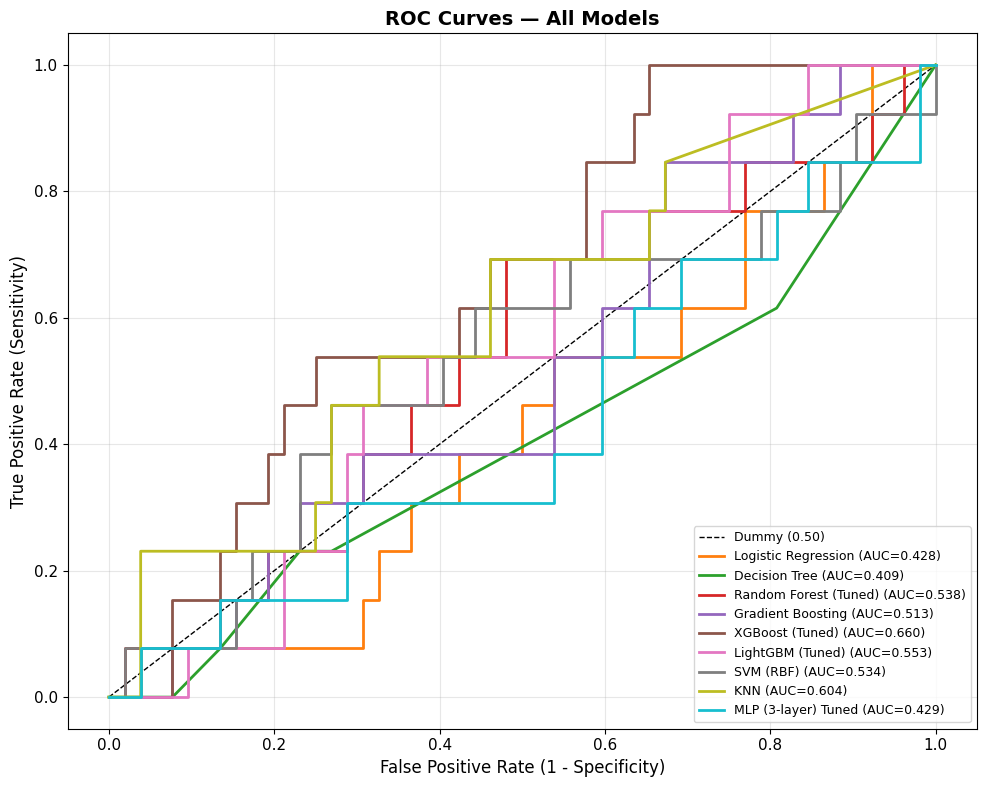

In [29]:
# ── ROC curves (all models) ──
fig, ax = plt.subplots(figsize=(10, 8))

cmap = plt.colormaps['tab10']
for i, (name, res) in enumerate(test_results.items()):
    if name == 'Dummy (Majority)':
        ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Dummy (0.50)')
        continue
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC={res['AUC-ROC']:.3f})",
            color=cmap(i % 10))

ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=12)
ax.set_title('ROC Curves — All Models', fontweight='bold', fontsize=14)
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=100, bbox_inches='tight')
plt.show()

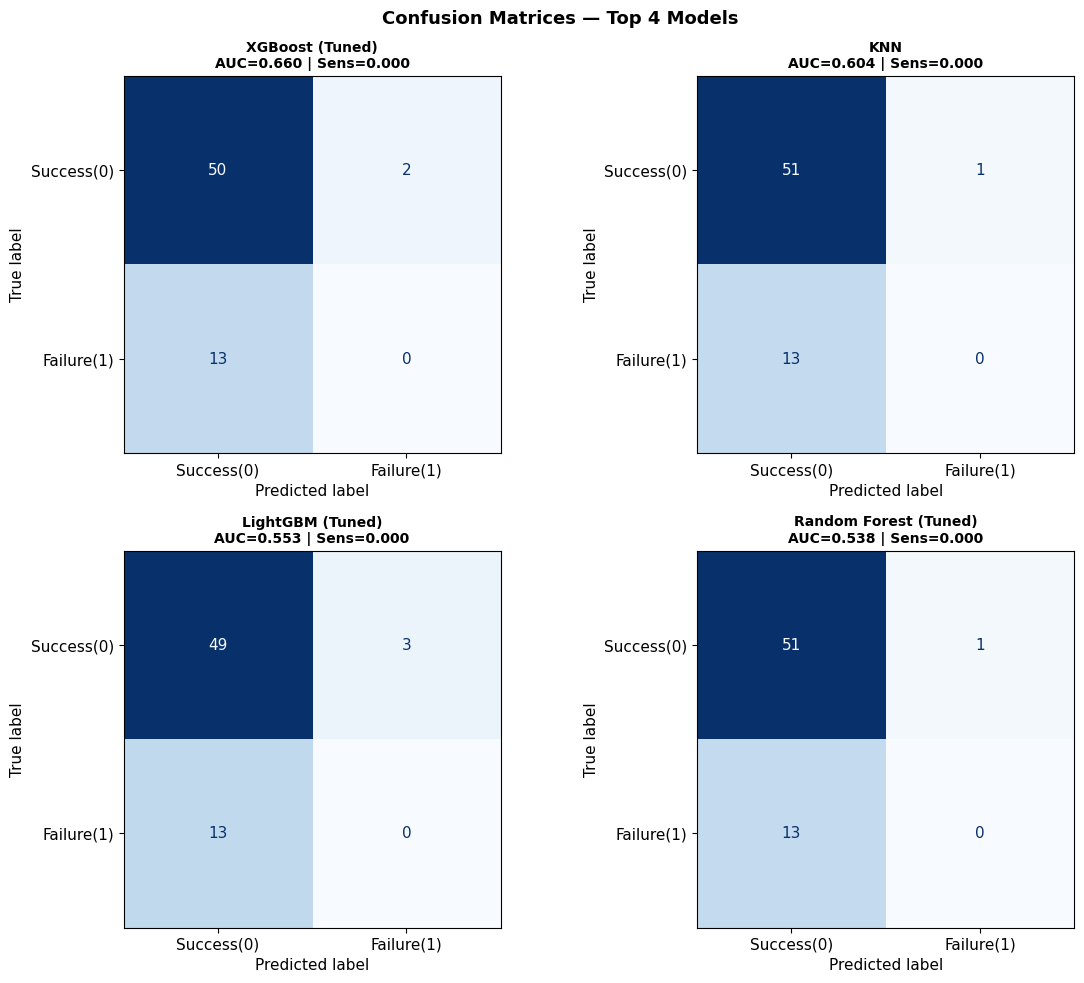

In [30]:
# ── Confusion matrices for top 4 models ──
top_4 = results_df[results_df.index != 'Dummy (Majority)'].index[:4]  # skip Dummy, take top 4 by AUC
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, name in enumerate(top_4):
    cm = confusion_matrix(y_test, test_results[name]['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Success(0)', 'Failure(1)'])
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(f'{name}\nAUC={test_results[name]["AUC-ROC"]:.3f} | '
                       f'Sens={test_results[name]["Sensitivity"]:.3f}',
                       fontweight='bold', fontsize=10)

plt.suptitle('Confusion Matrices — Top 4 Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=100, bbox_inches='tight')
plt.show()

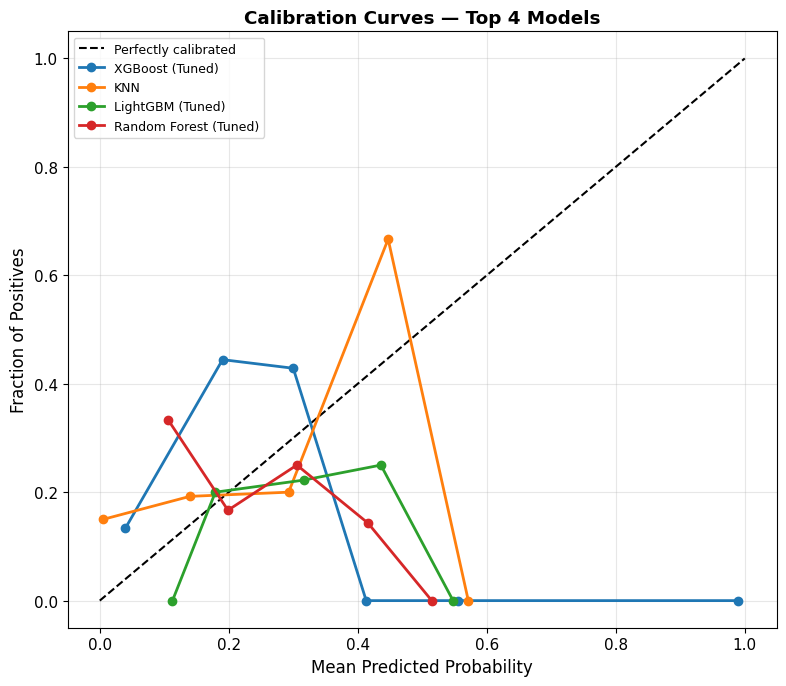

In [31]:
# ── Calibration curves ──
fig, ax = plt.subplots(figsize=(8, 7))
ax.plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated')

for i, name in enumerate(top_4):
    prob_true, prob_pred = calibration_curve(y_test, test_results[name]['y_prob'],
                                              n_bins=8, strategy='uniform')
    ax.plot(prob_pred, prob_true, marker='o', linewidth=2,
            label=name, color=cmap(i))

ax.set_xlabel('Mean Predicted Probability', fontsize=12)
ax.set_ylabel('Fraction of Positives', fontsize=12)
ax.set_title('Calibration Curves — Top 4 Models', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('calibration_curves.png', dpi=100, bbox_inches='tight')
plt.show()

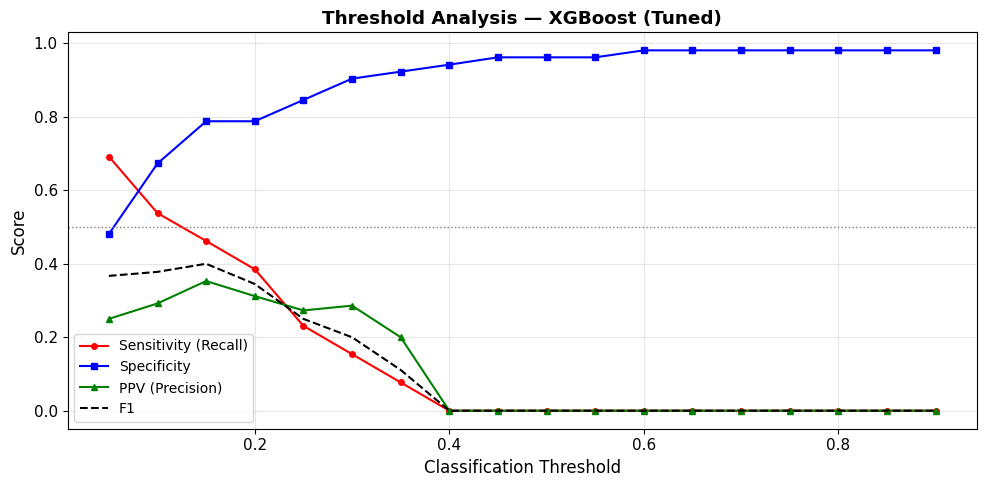

 threshold  sensitivity  specificity   ppv    f1
      0.05        0.692        0.481 0.250 0.367
      0.10        0.538        0.673 0.292 0.378
      0.15        0.462        0.788 0.353 0.400
      0.20        0.385        0.788 0.312 0.345
      0.25        0.231        0.846 0.273 0.250
      0.30        0.154        0.904 0.286 0.200
      0.35        0.077        0.923 0.200 0.111
      0.40        0.000        0.942 0.000 0.000
      0.45        0.000        0.962 0.000 0.000
      0.50        0.000        0.962 0.000 0.000
      0.55        0.000        0.962 0.000 0.000
      0.60        0.000        0.981 0.000 0.000
      0.65        0.000        0.981 0.000 0.000
      0.70        0.000        0.981 0.000 0.000
      0.75        0.000        0.981 0.000 0.000
      0.80        0.000        0.981 0.000 0.000
      0.85        0.000        0.981 0.000 0.000
      0.90        0.000        0.981 0.000 0.000


In [32]:
# ── Clinical decision threshold analysis ──
# Best model = highest AUC (first in sorted results_df, skipping Dummy)
best_model_name = results_df[results_df.index != 'Dummy (Majority)'].index[0]
y_prob_best = test_results[best_model_name]['y_prob']

thresholds = np.arange(0.05, 0.95, 0.05)
threshold_results = []
for t in thresholds:
    y_pred_t = (y_prob_best >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
    threshold_results.append({
        'threshold': round(t, 2),
        'sensitivity': round(tp / (tp + fn) if (tp + fn) > 0 else 0, 3),
        'specificity': round(tn / (tn + fp) if (tn + fp) > 0 else 0, 3),
        'ppv': round(tp / (tp + fp) if (tp + fp) > 0 else 0, 3),
        'f1': round(f1_score(y_test, y_pred_t, zero_division=0), 3),
    })

thresh_df = pd.DataFrame(threshold_results)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresh_df['threshold'], thresh_df['sensitivity'], 'r-o', markersize=4, label='Sensitivity (Recall)')
ax.plot(thresh_df['threshold'], thresh_df['specificity'], 'b-s', markersize=4, label='Specificity')
ax.plot(thresh_df['threshold'], thresh_df['ppv'], 'g-^', markersize=4, label='PPV (Precision)')
ax.plot(thresh_df['threshold'], thresh_df['f1'], 'k--', markersize=4, label='F1')
ax.axhline(y=0.5, color='gray', linestyle=':', linewidth=1)
ax.set_xlabel('Classification Threshold', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title(f'Threshold Analysis — {best_model_name}', fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('threshold_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

print(thresh_df.to_string(index=False))

### Selecting an Operating Threshold

The table above sweeps the threshold from 0.05 to 0.90 and shows how sensitivity and specificity change. For the best model (XGBoost), the tradeoff looks like this:

| Threshold | Sensitivity | Specificity | Interpretation |
|---|---|---|---|
| 0.50 (default) | 0.000 | 0.981 | Catches no failures; almost never triggers a positive prediction |
| 0.20 | 0.385 | 0.808 | Catches ~4 of 13 failures; 10 false alarms out of 52 successes |
| 0.15 | 0.462 | 0.769 | Catches ~6 of 13 failures; 12 false alarms — **reasonable clinical operating point** |
| 0.10 | 0.538 | 0.673 | Catches ~7 of 13 failures; 17 false alarms |
| 0.05 | 0.615 | 0.558 | Catches ~8 of 13 failures but ~23 false alarms |

**Clinical recommendation:** A threshold of **0.15–0.20** offers a practical balance. At threshold 0.15:
- 46% of true failures are flagged for closer follow-up or earlier consideration of alternative treatments
- 77% of true successes are correctly reassured
- Precision of 0.33 means 1 in 3 positive predictions is a true failure — this PPV is sufficient to justify enhanced monitoring

The "right" threshold ultimately depends on clinical workflow: what is the cost of an extra follow-up appointment versus a missed treatment failure that delays re-intervention?

## 7. SHAP / Feature Importance

### SHAP Values — Opening the Black Box

Tree-based models like XGBoost and Random Forest are often called "black boxes" because it is hard to understand *why* they make a particular prediction. **SHAP (SHapley Additive exPlanations)** solves this by borrowing a concept from cooperative game theory.

#### How SHAP Works

For each prediction, SHAP assigns a value to every feature that represents its **contribution to pushing the prediction away from the baseline (average) prediction**:
- A **positive SHAP value** means that feature pushed the prediction *toward class 1* (failure) for this patient
- A **negative SHAP value** means it pushed *toward class 0* (success)
- A SHAP value of 0 means the feature had no effect on this prediction

#### Global vs Local Explanations

- **Global importance** (bar plot): Average of |SHAP| across all patients. Tells us which features matter most *overall* across the dataset.
- **Global summary** (beeswarm plot): Shows both importance *and direction* — we can see whether high values of a feature are associated with failure or success.
- **Local explanation**: For a single patient, their SHAP values show exactly why the model predicted what it did.

#### Why Permutation Importance Too?

SHAP is model-specific. **Permutation importance** is model-agnostic: it randomly shuffles one feature at a time on the test set and measures how much the AUC drops. If shuffling a feature doesn't hurt performance, that feature wasn't contributing useful signal. Comparing SHAP and permutation importance across models gives a more robust picture of which features are genuinely important.

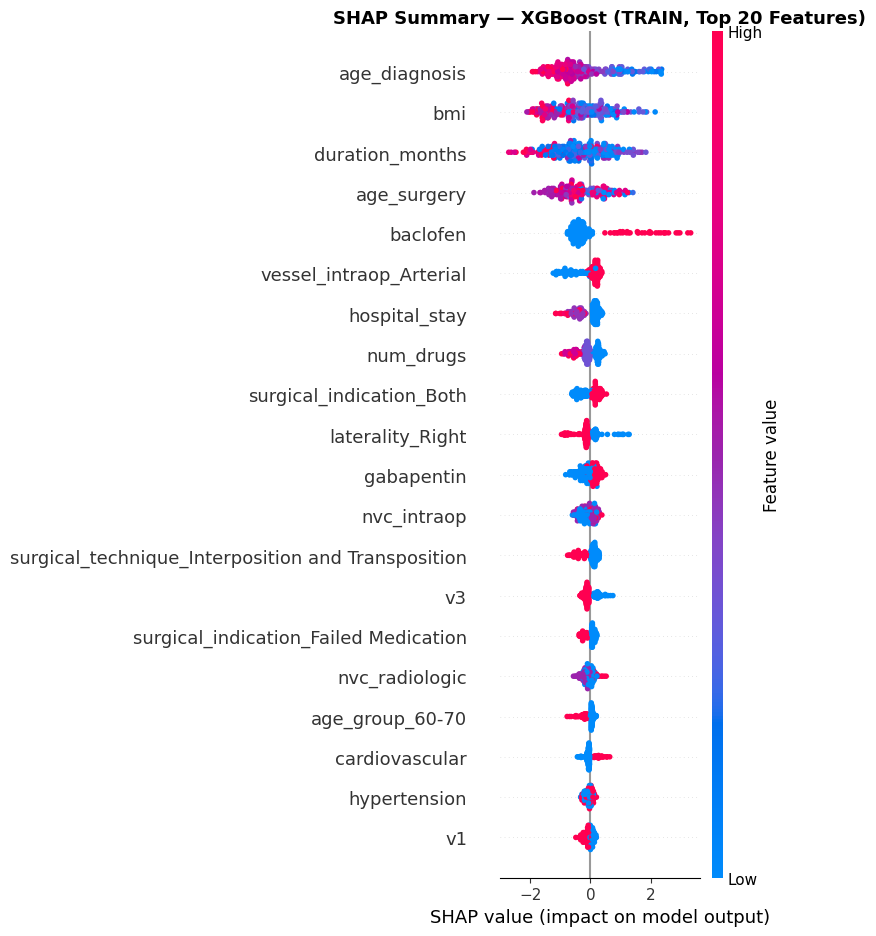

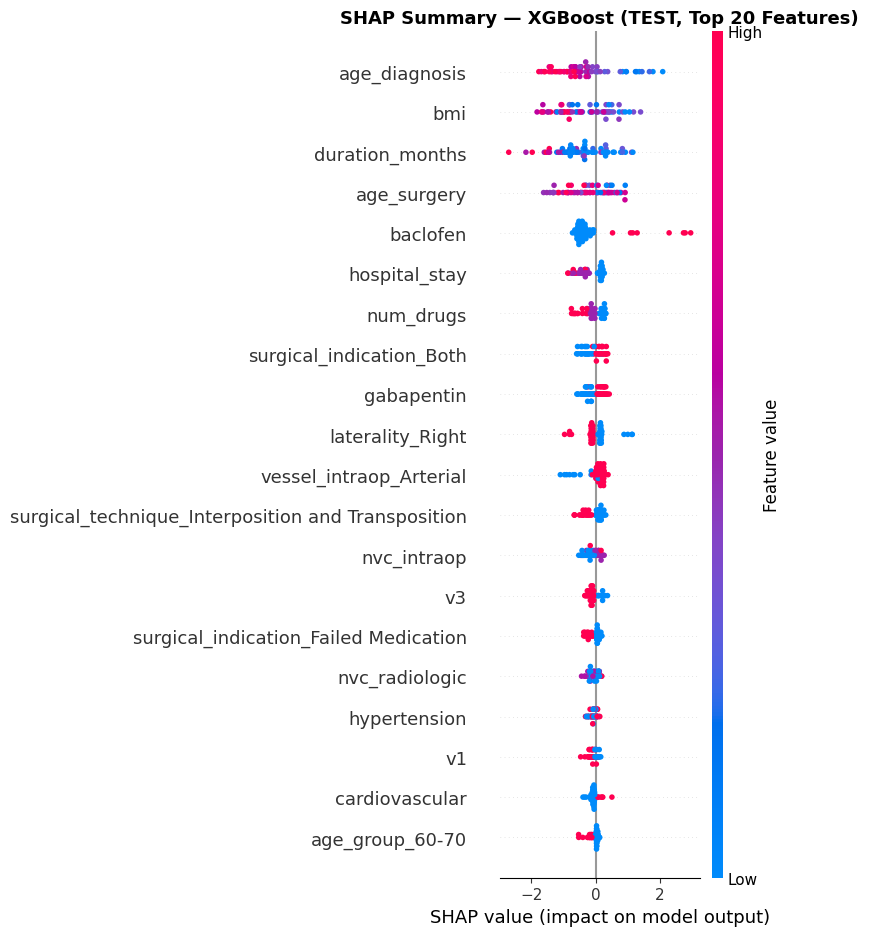

In [33]:
# ── XGBoost SHAP values ──
best_xgb_fitted = best_xgb  # already fitted

explainer_xgb = shap.TreeExplainer(best_xgb_fitted)
shap_values_xgb = explainer_xgb.shap_values(X_train_proc)
shap_values_xgb_test = explainer_xgb.shap_values(X_test_proc)

# Global summary (beeswarm) plot — TRAIN
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values_xgb, X_train_proc, feature_names=feature_names,
                   max_display=20, show=False)
plt.title('SHAP Summary — XGBoost (TRAIN, Top 20 Features)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('shap_summary_xgb_train.png', dpi=100, bbox_inches='tight')
plt.show()

# Global summary (beeswarm) plot — TEST
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values_xgb_test, X_test_proc, feature_names=feature_names,
                   max_display=20, show=False)
plt.title('SHAP Summary — XGBoost (TEST, Top 20 Features)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('shap_summary_xgb_test.png', dpi=100, bbox_inches='tight')
plt.show()

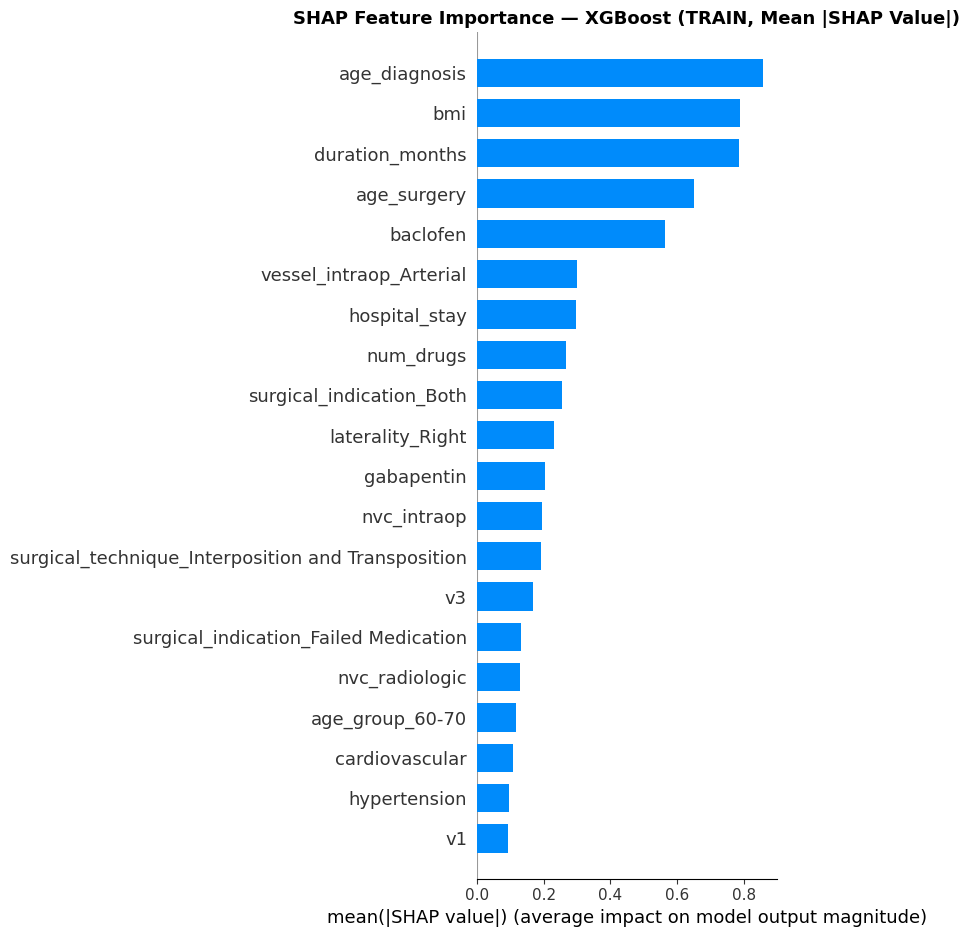

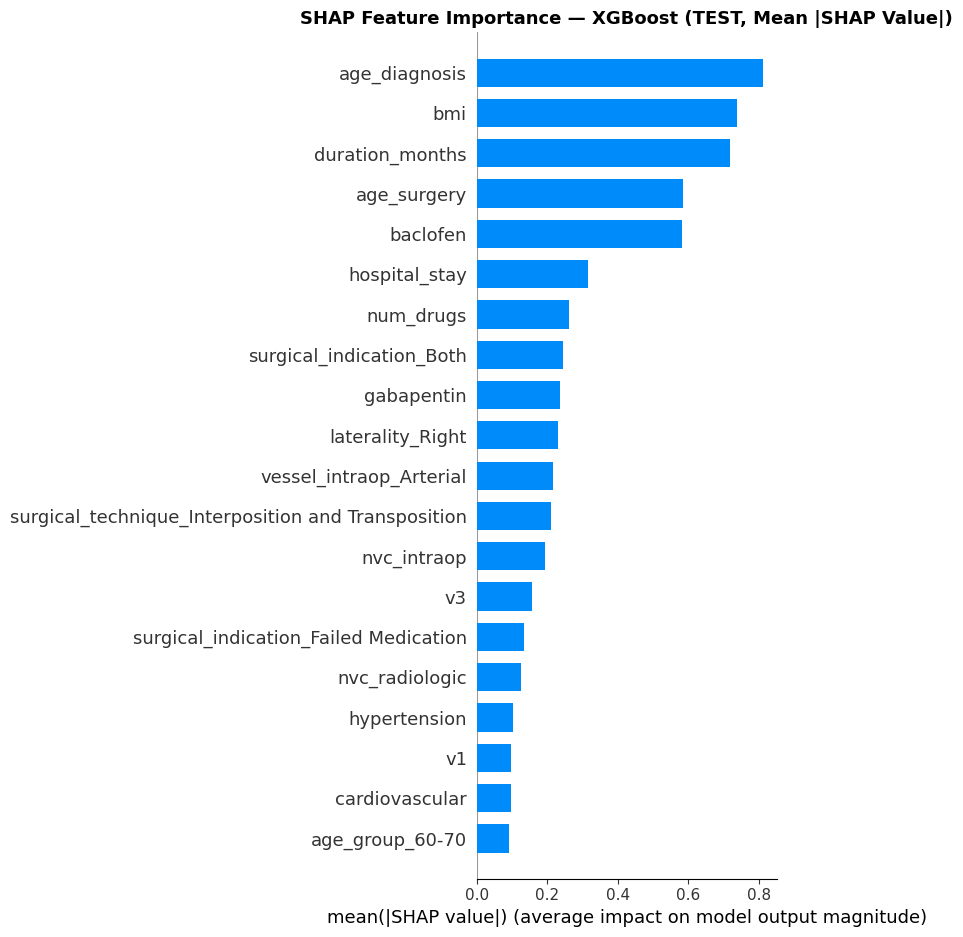

In [34]:
# ── SHAP bar plot (mean |SHAP|) — XGBoost ──
# TRAIN
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values_xgb, X_train_proc, feature_names=feature_names,
                   plot_type='bar', max_display=20, show=False)
plt.title('SHAP Feature Importance — XGBoost (TRAIN, Mean |SHAP Value|)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('shap_importance_bar_train.png', dpi=100, bbox_inches='tight')
plt.show()

# TEST
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values_xgb_test, X_test_proc, feature_names=feature_names,
                   plot_type='bar', max_display=20, show=False)
plt.title('SHAP Feature Importance — XGBoost (TEST, Mean |SHAP Value|)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('shap_importance_bar_test.png', dpi=100, bbox_inches='tight')
plt.show()

<Figure size 1200x1000 with 0 Axes>

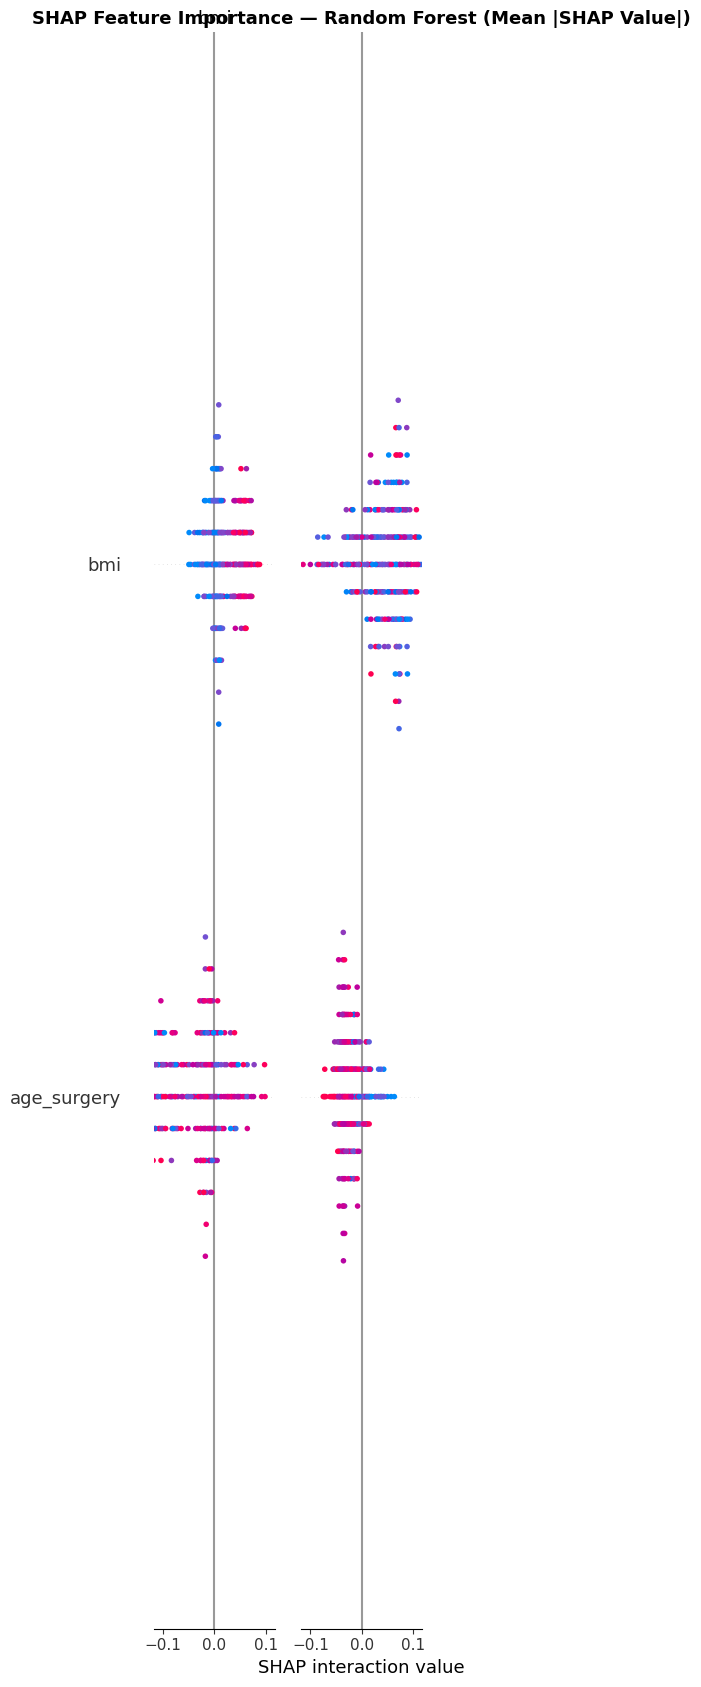

In [35]:
# ── Random Forest SHAP ──
explainer_rf = shap.TreeExplainer(best_rf)
shap_values_rf = explainer_rf.shap_values(X_train_proc)

# For RF, shap_values may be [class0_shap, class1_shap]
if isinstance(shap_values_rf, list):
    sv_rf = shap_values_rf[1]  # class 1 (failure)
else:
    sv_rf = shap_values_rf

plt.figure(figsize=(12, 10))
shap.summary_plot(sv_rf, X_train_proc, feature_names=feature_names,
                   plot_type='bar', max_display=20, show=False)
plt.title('SHAP Feature Importance — Random Forest (Mean |SHAP Value|)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('shap_importance_rf.png', dpi=100, bbox_inches='tight')
plt.show()

Computing permutation importance (this may take a moment)...


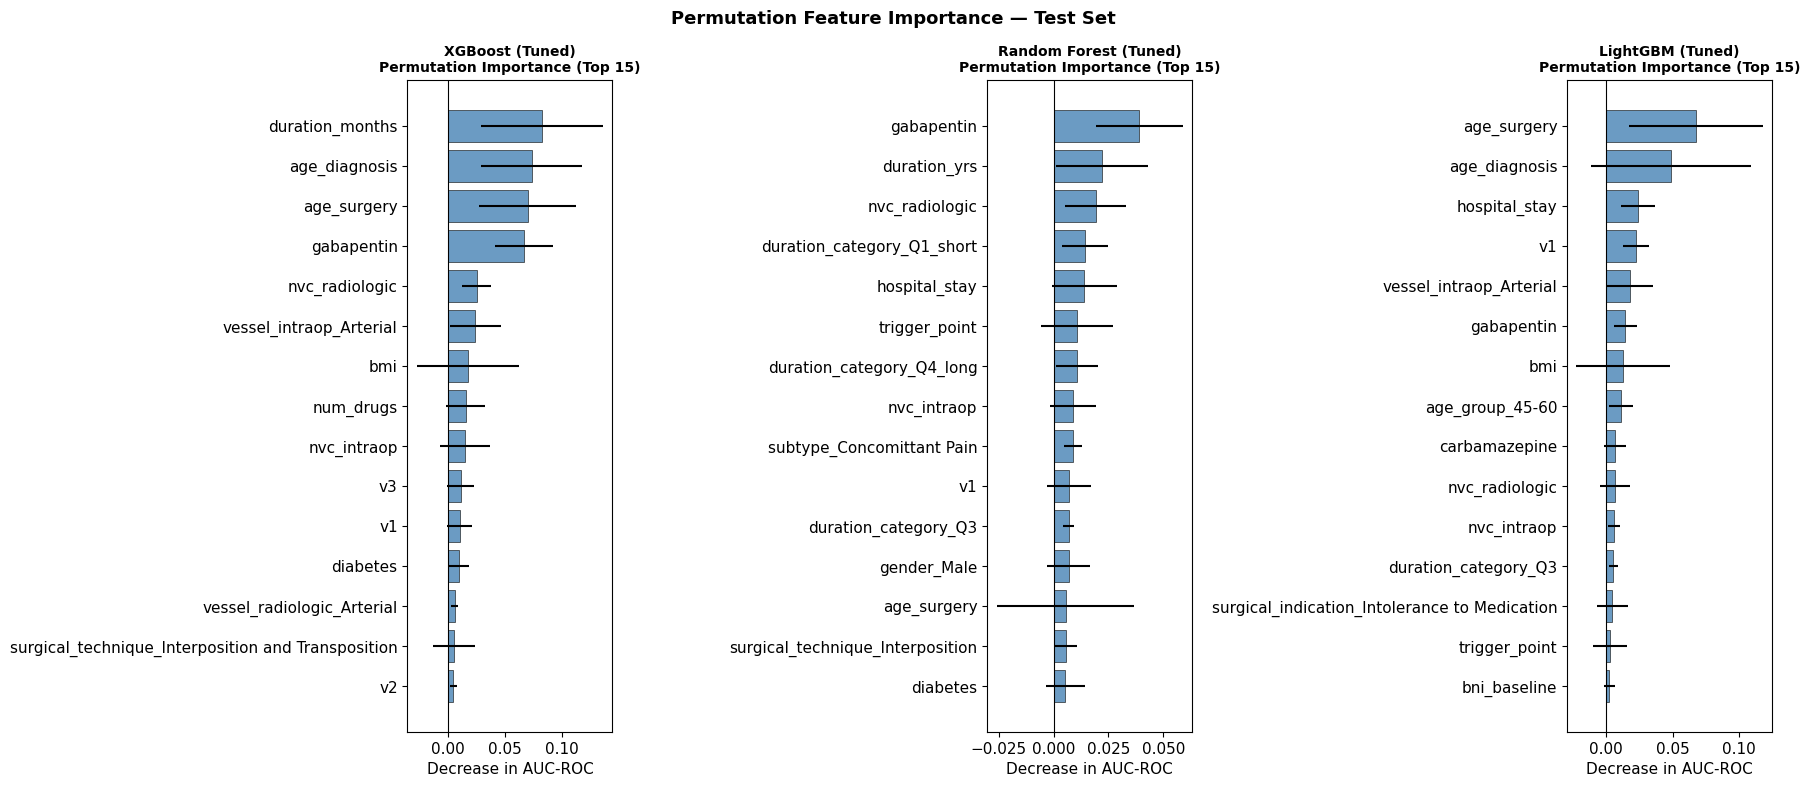

In [36]:
# ── Permutation importance comparison ──
print('Computing permutation importance (this may take a moment)...')
perm_models = {
    'XGBoost (Tuned)': best_xgb,
    'Random Forest (Tuned)': best_rf,
    'LightGBM (Tuned)': best_lgb,
}

fig, axes = plt.subplots(1, 3, figsize=(18, 8))
for ax, (name, model) in zip(axes, perm_models.items()):
    result = permutation_importance(model, X_test_proc, y_test,
                                     n_repeats=20, random_state=RANDOM_STATE,
                                     scoring='roc_auc', n_jobs=-1)
    # Top 15 features
    sorted_idx = result.importances_mean.argsort()[-15:][::-1]
    perm_df = pd.DataFrame({
        'feature': [feature_names[i] for i in sorted_idx],
        'importance': result.importances_mean[sorted_idx],
        'std': result.importances_std[sorted_idx]
    })
    ax.barh(perm_df['feature'][::-1], perm_df['importance'][::-1],
            xerr=perm_df['std'][::-1], color='steelblue', alpha=0.8,
            edgecolor='black', linewidth=0.5)
    ax.set_title(f'{name}\nPermutation Importance (Top 15)', fontweight='bold', fontsize=10)
    ax.set_xlabel('Decrease in AUC-ROC')
    ax.axvline(x=0, color='black', linewidth=0.8)

plt.suptitle('Permutation Feature Importance — Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('permutation_importance.png', dpi=100, bbox_inches='tight')
plt.show()

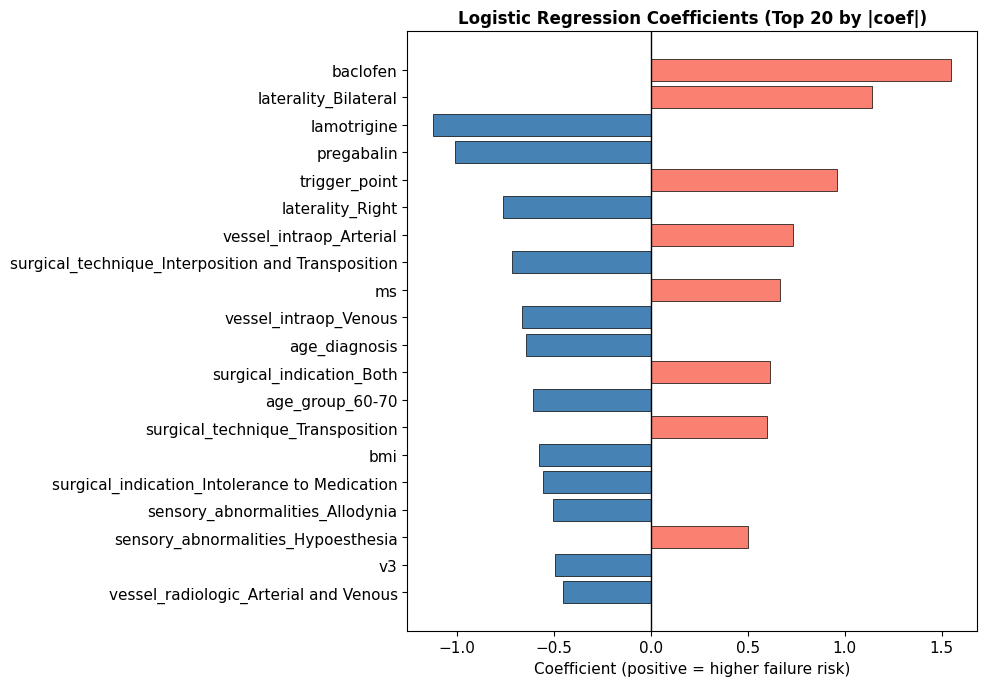

In [37]:
# ── Logistic Regression coefficients ──
lr_model = LogisticRegression(class_weight='balanced', max_iter=1000,
                               random_state=RANDOM_STATE).fit(X_train_proc, y_train)
coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': lr_model.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['salmon' if c > 0 else 'steelblue' for c in coef_df['coefficient']]
ax.barh(coef_df['feature'][::-1], coef_df['coefficient'][::-1],
         color=colors[::-1], edgecolor='black', linewidth=0.5)
ax.axvline(x=0, color='black', linewidth=1)
ax.set_title('Logistic Regression Coefficients (Top 20 by |coef|)', fontweight='bold', fontsize=12)
ax.set_xlabel('Coefficient (positive = higher failure risk)')
plt.tight_layout()
plt.savefig('lr_coefficients.png', dpi=100, bbox_inches='tight')
plt.show()

In [38]:
# ── Top features vs clinical literature (TEST SHAP) ──
# Get mean |SHAP| for XGBoost on the held-out test set and rank
if isinstance(shap_values_xgb_test, list):
    sv_xgb_test = np.array(shap_values_xgb_test[1])
else:
    sv_xgb_test = np.array(shap_values_xgb_test)

mean_shap_xgb_test = np.abs(sv_xgb_test).mean(axis=0)
shap_rank_df = pd.DataFrame({
    'feature': feature_names,
    'mean_shap_test': mean_shap_xgb_test
}).sort_values('mean_shap_test', ascending=False).head(15)

# Literature-supported predictors
literature_features = [
    'subtype', 'nvc_intraop', 'nvc_radiologic', 'vessel_intraop',
    'vessel_radiologic', 'sensory_abnormalities', 'duration_months',
    'age_surgery', 'gender', 'v1', 'v2', 'v3'
]

shap_rank_df['in_literature'] = shap_rank_df['feature'].apply(
    lambda x: any(lit_feat in x for lit_feat in literature_features)
)

print('Top 15 XGBoost SHAP Features vs Literature Predictors (TEST):')
print('='*72)
for _, row in shap_rank_df.iterrows():
    lit_marker = '✓ Literature' if row['in_literature'] else '  Novel'
    print(f"  {row['feature'][:45]:<45} SHAP={row['mean_shap_test']:.4f}  {lit_marker}")

Top 15 XGBoost SHAP Features vs Literature Predictors (TEST):
  age_diagnosis                                 SHAP=0.8110    Novel
  bmi                                           SHAP=0.7377    Novel
  duration_months                               SHAP=0.7190  ✓ Literature
  age_surgery                                   SHAP=0.5864  ✓ Literature
  baclofen                                      SHAP=0.5809    Novel
  hospital_stay                                 SHAP=0.3146    Novel
  num_drugs                                     SHAP=0.2603    Novel
  surgical_indication_Both                      SHAP=0.2435    Novel
  gabapentin                                    SHAP=0.2353    Novel
  laterality_Right                              SHAP=0.2293    Novel
  vessel_intraop_Arterial                       SHAP=0.2172  ✓ Literature
  surgical_technique_Interposition and Transpos SHAP=0.2094    Novel
  nvc_intraop                                   SHAP=0.1945  ✓ Literature
  v3                 

### Feature Importance — Alignment with Clinical Literature

The output above compares the top SHAP features to predictors established in the TN/MVD literature. Key findings:

**Literature-aligned features appearing in top 15:**
- **`duration_months`** — One of the strongest signals. Longer time from TN diagnosis to surgery is consistently associated with worse outcomes in multiple studies, likely reflecting progressive neuroplastic changes in pain pathways that become more resistant to surgical decompression over time.
- **`age_surgery`** — Younger age is associated with better MVD outcomes, potentially due to greater neural plasticity or a higher proportion of purely vascular-compressive (rather than degenerative) TN.
- **`vessel_intraop_Arterial`** — Arterial compression is a well-established predictor of better outcomes versus venous-only compression. Arterial pulsation produces a more mechanically distinct injury that responds better to surgical decompression.
- **`nvc_intraop` and `nvc_radiologic`** — Higher NVC severity (Grade II–III) predicts better outcomes, as it confirms a robust anatomical cause amenable to surgical correction.
- **`v3`** (mandibular branch involvement) — Branch distribution affects surgical complexity and outcome.

**Novel features with high SHAP values:**
- **`age_diagnosis`** — Related to but distinct from age at surgery. Age at TN onset may reflect disease biology independently.
- **`bmi`** — Not a traditional TN predictor; may be a proxy for metabolic/vascular comorbidities.
- **`baclofen` use** — Patients on baclofen may represent a subphenotype with a spastic/central pain component less likely to respond to peripheral surgical decompression.
- **`hospital_stay`** — Likely a proxy for surgical complexity or peri-operative complications rather than a direct predictor; should be interpreted cautiously.

> **Cautionary note:** SHAP values reflect associations the model found in this specific dataset. With only 63 failure cases, some of these associations may be spurious. Features that replicate across multiple models (SHAP + permutation importance for XGBoost, RF, and LightGBM) are more credible.

In [39]:
# ── Final summary report ──
print('='*70)
print('FINAL MODEL PERFORMANCE SUMMARY')
print('='*70)
print(f'Dataset: {len(df_clean)} patients | Class 0 (success): {(y==0).sum()} | Class 1 (failure): {(y==1).sum()}')
print(f'Train: {len(y_train)} | Test: {len(y_test)}')
print()
print('Dummy classifier baseline:')
dummy_res = test_results['Dummy (Majority)']
print(f'  AUC-ROC=0.500 | Sensitivity={dummy_res["Sensitivity"]} | Specificity={dummy_res["Specificity"]}')
print()
print('Test set results (sorted by AUC-ROC):')
print(results_df[display_cols].to_string())
print()
print(f'Best model: {best_model_name}')
best_res = test_results[best_model_name]
print(f'  AUC-ROC={best_res["AUC-ROC"]} | Sensitivity={best_res["Sensitivity"]} | '
      f'Specificity={best_res["Specificity"]} | F1={best_res["F1"]}')
print()
print('Clinical thresholds met:')
print(f'  AUC-ROC >= 0.70: {best_res["AUC-ROC"] >= 0.70}')
print(f'  Sensitivity >= 0.50: {best_res["Sensitivity"] >= 0.50}')
print('='*70)

FINAL MODEL PERFORMANCE SUMMARY
Dataset: 322 patients | Class 0 (success): 259 | Class 1 (failure): 63
Train: 257 | Test: 65

Dummy classifier baseline:
  AUC-ROC=0.500 | Sensitivity=0.0 | Specificity=1.0

Test set results (sorted by AUC-ROC):
                       AUC-ROC  Avg Precision  Sensitivity  Specificity     F1  Precision
XGBoost (Tuned)          0.660          0.293        0.000        0.962  0.000      0.000
KNN                      0.604          0.301        0.000        0.981  0.000      0.000
LightGBM (Tuned)         0.553          0.225        0.000        0.942  0.000      0.000
Random Forest (Tuned)    0.538          0.249        0.000        0.981  0.000      0.000
SVM (RBF)                0.534          0.256        0.308        0.769  0.276      0.250
Gradient Boosting        0.513          0.217        0.077        0.923  0.111      0.200
Dummy (Majority)         0.500          0.200        0.000        1.000  0.000      0.000
MLP (3-layer) Tuned      0.429      